## **Descriptive Analysis of Air Quality in Yogyakarta, Indonesia using the 2021 Database**
- **Group Number:** 12
- **Name:**
1. Muhammad Akbar Rizky Hidayat - 5027261032
2. Dhafin Abhinaya Setyawan - 5027261083
3. Jenifer Tri Fena Andhika - 5027261123
- **Topic:** Smart City

### **Background**
Air quality is one of the key indicators for assessing a city’s sustainability, especially amid the rapid growth of transportation and industrial activities across various regions of Indonesia. The “Air Quality in Yogyakarta, Indonesia (2021)” dataset contains air pollution measurement data for Yogyakarta throughout 2021. Our group chose this dataset because Yogyakarta is one of Indonesia’s major cities with high population and vehicle mobility levels, making the data relevant for providing a general picture of urban air quality. Through descriptive statistics analysis of this data, we aim to illustrate the patterns and levels of air quality in Yogyakarta throughout the year, while connecting them to the Sustainable Development Goals (SDGs), specifically SDG 3 (Good Health and Well-being), as air quality directly impacts public respiratory health, and SDG 11 (Sustainable Cities and Communities) because air quality monitoring is a crucial part of efforts to create safe, inclusive, and sustainable cities. Thus, the results of this analysis are expected to serve as a simple example of how a city’s air quality data can be used to raise awareness and data-driven decision-making toward more sustainable urban development.

### **Research Questions:**
1. What are the mode, median, mean, range, and variance of PM2.5 and PM10 concentrations in Yogyakarta for each month throughout the year?
2. Which hours of the day show the highest and lowest average pollutant concentrations?
3. What proportion of hours or days fall into each category (Good, Moderate, Unhealthy, Very Unhealthy, Dangerous)?

### **Data Description and Dictionary**
- Source of data: The data comes from the Yogyakarta Environmental Agency (Dinas Lingkungan Hidup Yogyakarta), which was processed and uploaded to Kaggle by Adhang MM at this link: https://www.kaggle.com/datasets/adhang/air-quality-in-yogyakarta-indonesia-2021
- License: Data files © Original Authors
- The data was collected by the Yogyakarta Environmental Agency in April 2021. Measurements were taken hourly. The original pollution values were converted into the Pollutant Standards Index (PSI/ISPU).
- The data has 11 columns for each month.
- January, March, May, July, August, October, and December consist of 744 rows.
- February consists of 674 rows.
- April, June, September, and November consist of 720 rows.

| Column | Definition | Variable Type | Scale | Units | Example |
| --- | --- | --- | --- | --- | --- |
| Date | The date measurement was taken | Qualitative | Interval | - | 4/1/2021 |
| Time | The time measurement was taken (hourly) | Qualitative | Interval | - | 00:00:00 | 
| PM2.5 | Particulate Matter 2.5 measurement (Index) | Quantitative Continuous | Ratio | PSI | 45 |
| PM10 | Particulate Matter 10 measurement (Index) | Quantitative Continuous | Ratio | PSI | 19 |
| SO2 | Sulfur Dioxide measurement (Index) | Quantitative Continuous | Ratio | PSI | 15 |
| CO | Carbon Monoxide measurement (Index) | Quantitative Continuous | Ratio | PSI | 15 |
| O3 | Ozone measurement (Index) | Quantitative Continuous | Ratio | PSI | 8 |
| NO2 | Nitrogen Dioxide measurement (Index) | Quantitative Continuous | Ratio | PSI | 3 |
| Max | Highest pollution measurement value at that hour | Quantitative Continuous | Ratio | PSI | 45 |
| Critical Component | Gas component contributing to the highest pollution | Qualitative | Nominal | - | PM2.5 |
| Category | Air quality category based on the Max value | Qualitative | Ordinal | - | Good |

### **Yogyakarta's Air Quality Dataset in January 2021**

In [3]:
import pandas as pd

df = pd.read_csv("dataset/01-jogja-jan-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,1/1/2021,00:00:00,13,40,0,25,0,0,40,PM2.5,Good
2,1/1/2021,01:00:00,12,38,0,24,0,0,38,PM2.5,Good
3,1/1/2021,02:00:00,11,35,0,23,0,0,35,PM2.5,Good
4,1/1/2021,03:00:00,10,32,0,22,0,0,32,PM2.5,Good
5,1/1/2021,04:00:00,9,29,0,21,0,0,29,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,1/31/2021,19:00:00,25,66,19,25,40,6,66,PM2.5,Moderate
741,1/31/2021,20:00:00,24,65,19,24,39,5,65,PM2.5,Moderate
742,1/31/2021,21:00:00,23,64,19,24,38,5,64,PM2.5,Moderate
743,1/31/2021,22:00:00,23,63,19,24,38,5,63,PM2.5,Moderate


#### <span style="color:blue">**Data Quality Check**</span>

In [11]:
filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/01-jogja-jan-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Date                744 non-null    str  
 1   Time                744 non-null    str  
 2   PM10                744 non-null    int64
 3   PM2.5               744 non-null    int64
 4   SO2                 744 non-null    int64
 5   CO                  744 non-null    int64
 6   O3                  744 non-null    int64
 7   NO2                 744 non-null    int64
 8   Max                 744 non-null    int64
 9   Critical Component  744 non-null    str  
 10  Category            744 non-null    str  
dtypes: int64(7), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [5]:
filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/01-jogja-jan-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000
mean,16.063172,46.782258,14.005376,24.534946,22.290323,2.469086,48.432796
std,8.358234,18.616724,10.531244,3.355775,17.578254,2.179462,16.666334
min,2.000000,12.000000,0.000000,17.000000,0.000000,0.000000,19.000000
25%,8.000000,30.000000,1.000000,22.000000,0.000000,0.000000,34.000000
50%,16.000000,52.000000,20.000000,25.000000,26.000000,3.000000,52.000000
75%,21.000000,60.000000,23.000000,27.000000,38.000000,4.000000,60.000000
max,35.000000,80.000000,28.000000,33.000000,55.000000,7.000000,80.000000


##### <span style="color:blue">**1. PM2.5**</span>

In [6]:
filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: dataset/01-jogja-jan-2021.csv
Mean: 46.78225806451613
Median: 52.0
Mode: 55
Variance: 346.58240350801026
Standard Deviation: 18.616723758707124
Q1 (25%): 30.0
Q3 (75%): 60.0


##### <span style="color:blue">**2. PM10**</span>

In [7]:
filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM10"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: dataset/01-jogja-jan-2021.csv
Mean: 16.063172043010752
Median: 16.0
Mode: 6
Variance: 69.8600685248701
Standard Deviation: 8.358233576831298
Q1 (25%): 8.0
Q3 (75%): 21.0


##### <span style="color:blue">**3. CO**</span>

In [8]:
filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["CO"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: dataset/01-jogja-jan-2021.csv
Mean: 24.53494623655914
Median: 25.0
Mode: 26
Variance: 11.261226645827003
Standard Deviation: 3.3557751184826143
Q1 (25%): 22.0
Q3 (75%): 27.0


##### <span style="color:blue">**4. O3**</span>

In [9]:
filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["O3"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: dataset/01-jogja-jan-2021.csv
Mean: 22.29032258064516
Median: 26.0
Mode: 0
Variance: 308.9950071636348
Standard Deviation: 17.57825381440474
Q1 (25%): 0.0
Q3 (75%): 38.0


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [10]:
filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/01-jogja-jan-2021.csv


Critical Component
PM2.5    82.930108
O3       11.424731
CO        4.704301
SO2       0.940860
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [11]:
filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/01-jogja-jan-2021.csv


Category
Moderate    53.897849
Good        46.102151
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/01-jogja-jan-2021.csv


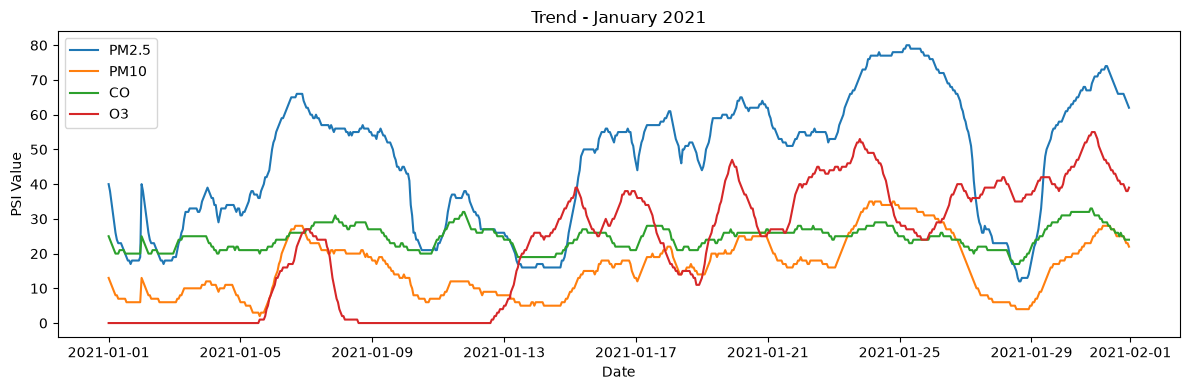

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the January data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - January 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In January 2021, PM2.5 stayed the highest and moved up and down the most (between about 20–80), O3 was almost zero for the first two weeks but then spiked a lot in the second half, while PM10 and CO stayed low and pretty steady the whole month.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/01-jogja-jan-2021.csv


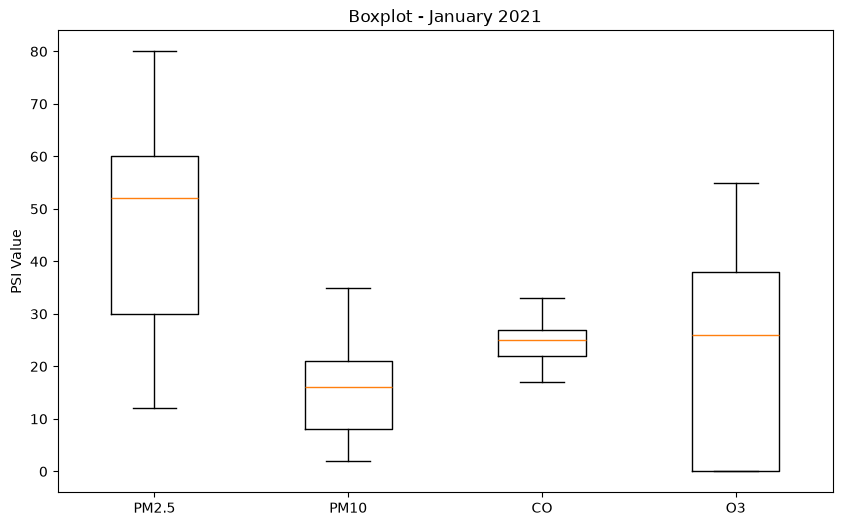

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - January 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

**None of the pollutants in January 2021 show outliers based on the 1.5×IQR rule, but PM2.5 has by far the widest spread (12–80) and the highest median (~52), while CO stays the most tightly packed, meaning PM2.5 levels varied a lot more day-to-day than the others.**

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/01-jogja-jan-2021.csv


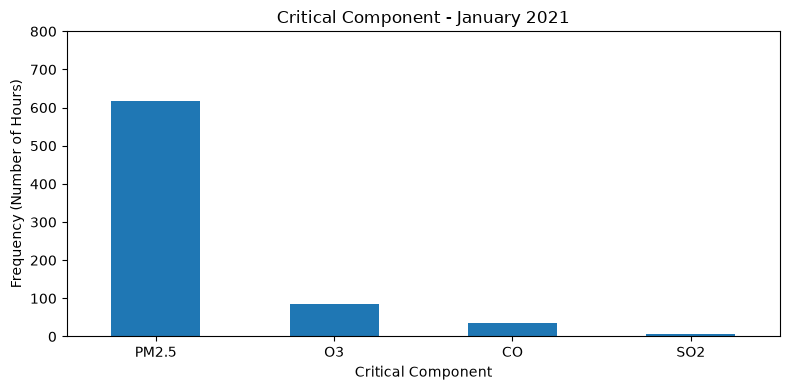

Critical Component
PM2.5    617
O3        85
CO        35
SO2        7
Name: count, dtype: int64

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - January 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()

**During January 2021, PM2.5 was the most frequent driver of poor air quality (617 hours), far exceeding O3, CO, and SO2, which each recorded under 100 hours.**

Data source: dataset/01-jogja-jan-2021.csv


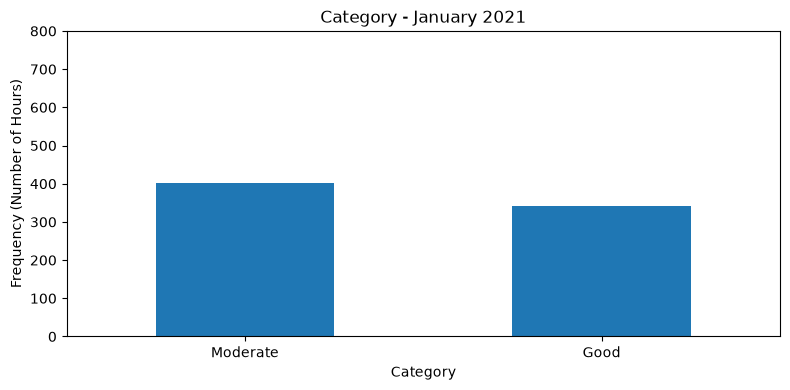

Category
Moderate    401
Good        343
Name: count, dtype: int64

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - January 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

**In January 2021, air quality was fairly evenly split between Moderate (401 hours) and Good (343 hours), with no single category clearly dominating the month.**

### **Yogyakarta's Air Quality Dataset in February 2021**

In [16]:
import pandas as pd

df = pd.read_csv("dataset/02-jogja-feb-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(672)

(672, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,2/1/2021,00:00:00,21,61,18,23,38.0,5,61,PM2.5,Moderate
2,2/1/2021,01:00:00,20,60,18,23,38.0,5,60,PM2.5,Moderate
3,2/1/2021,02:00:00,20,59,18,23,39.0,5,59,PM2.5,Moderate
4,2/1/2021,03:00:00,20,59,18,24,39.0,5,59,PM2.5,Moderate
5,2/1/2021,04:00:00,20,60,18,24,39.0,5,60,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
668,2/28/2021,19:00:00,9,34,17,10,33.0,6,34,PM2.5,Good
669,2/28/2021,20:00:00,9,35,17,11,33.0,6,35,PM2.5,Good
670,2/28/2021,21:00:00,10,37,18,12,34.0,6,37,PM2.5,Good
671,2/28/2021,22:00:00,11,40,18,13,34.0,6,40,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [17]:
filename = "dataset/02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/02-jogja-feb-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                672 non-null    str    
 1   Time                672 non-null    str    
 2   PM10                672 non-null    int64  
 3   PM2.5               672 non-null    int64  
 4   SO2                 672 non-null    int64  
 5   CO                  672 non-null    int64  
 6   O3                  657 non-null    float64
 7   NO2                 672 non-null    int64  
 8   Max                 672 non-null    int64  
 9   Critical Component  672 non-null    str    
 10  Category            672 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 57.9 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [18]:
filename = "dataset/02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/02-jogja-feb-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,672.000000,672.000000,672.000000,672.000000,657.000000,672.000000,672.000000
mean,18.760417,57.680060,20.964286,23.467262,34.925419,4.153274,58.943452
std,5.818725,11.901872,2.458945,5.749785,14.579750,1.379655,10.728450
min,7.000000,26.000000,16.000000,7.000000,9.000000,2.000000,27.000000
25%,15.000000,52.000000,19.000000,23.000000,24.000000,3.000000,53.000000
50%,19.000000,59.000000,20.000000,24.000000,35.000000,4.000000,60.000000
75%,24.000000,66.000000,22.000000,26.000000,41.000000,5.000000,67.000000
max,30.000000,80.000000,31.000000,38.000000,71.000000,8.000000,80.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [19]:
filename = "dataset/02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/02-jogja-feb-2021.csv


Critical Component
PM2.5    87.053571
O3       12.946429
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [20]:
filename = "dataset/02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/02-jogja-feb-2021.csv


Category
Moderate    82.738095
Good        17.261905
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/02-jogja-feb-2021.csv


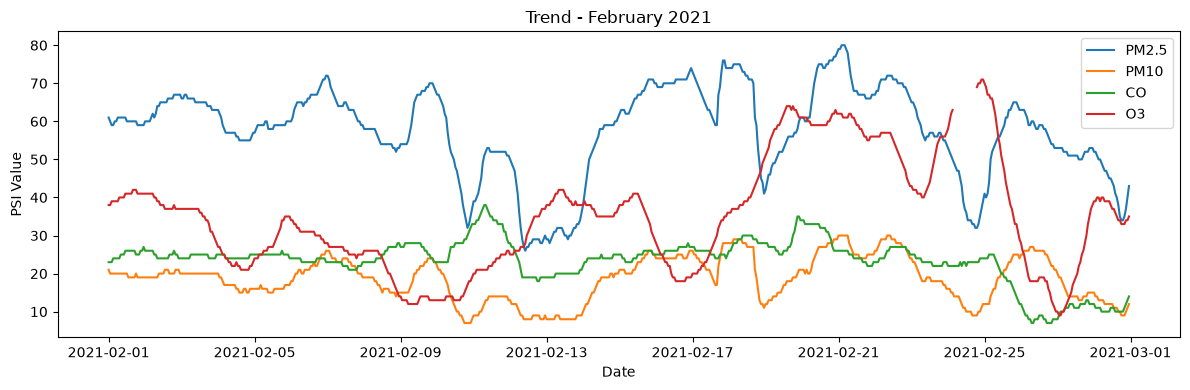

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/02-jogja-feb-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the February data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - February 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In February 2021, PM2.5 stayed the highest most of the month (mostly 40–80), O3 also went up and down a lot and even crossed PM2.5 a few times, while PM10 and CO stayed lower and calmer overall.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/02-jogja-feb-2021.csv


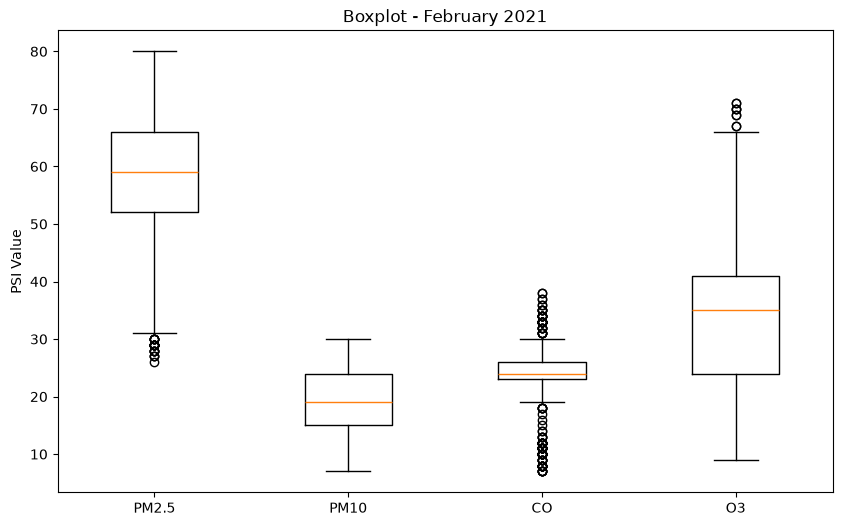

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - February 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

**

In [4]:
print(df[["O3"]].describe())
print(df["O3"].isna().sum())

               O3
count  657.000000
mean    34.925419
std     14.579750
min      9.000000
25%     24.000000
50%     35.000000
75%     41.000000
max     71.000000
15


##### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/02-jogja-feb-2021.csv


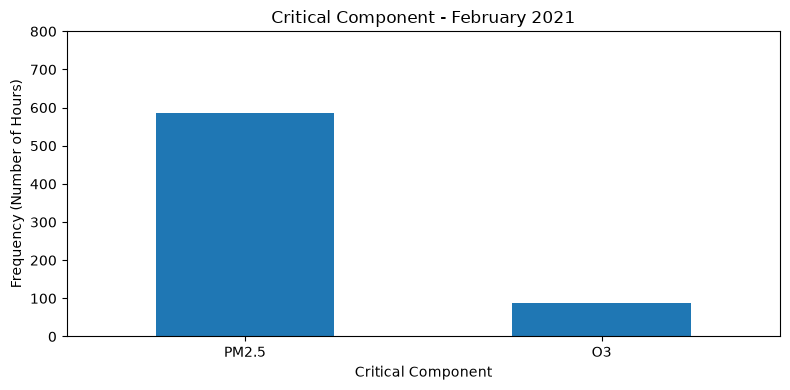

Critical Component
PM2.5    585
O3        87
Name: count, dtype: int64

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

# Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - February 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  # Display the counts for each bar of Critical Component

**In February 2021, PM2.5 was again the main driver of poor air quality (585 hours), far ahead of O3, CO, and SO2, which each stayed under 100 hours, which is the same pattern as January**

Data source: dataset/02-jogja-feb-2021.csv


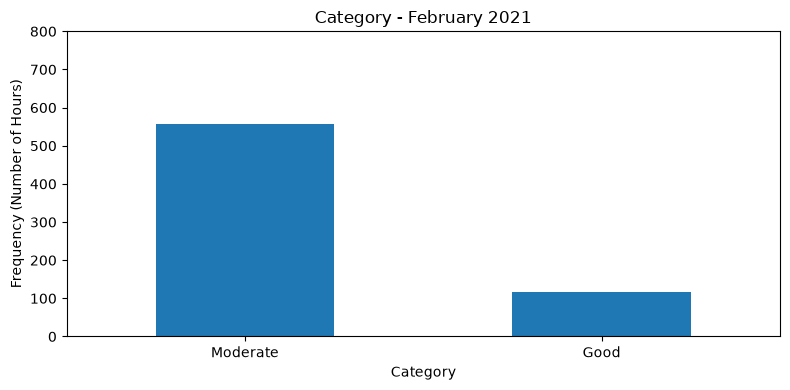

Category
Moderate    556
Good        116
Name: count, dtype: int64

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - February 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

**In February 2021, air quality showed significant differences between Moderate (556 hours) and Good (116 hours).**

### **Yogyakarta's Air Quality Dataset in March 2021**

In [26]:
import pandas as pd

df = pd.read_csv("dataset/03-jogja-mar-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,3/1/2021,00:00:00,13,48,19,15,35,6,48,PM2.5,Good
2,3/1/2021,01:00:00,14,51,19,16,36,6,51,PM2.5,Moderate
3,3/1/2021,02:00:00,15,52,20,17,37,6,52,PM2.5,Moderate
4,3/1/2021,03:00:00,16,54,20,17,37,6,54,PM2.5,Moderate
5,3/1/2021,04:00:00,17,55,21,18,38,6,55,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
740,3/31/2021,19:00:00,21,50,22,17,8,3,50,PM2.5,Good
741,3/31/2021,20:00:00,21,50,21,16,8,3,50,PM2.5,Good
742,3/31/2021,21:00:00,20,49,21,16,8,3,49,PM2.5,Good
743,3/31/2021,22:00:00,20,48,21,16,8,3,48,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [27]:
filename = "dataset/03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/03-jogja-mar-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Date                744 non-null    str  
 1   Time                744 non-null    str  
 2   PM10                744 non-null    int64
 3   PM2.5               744 non-null    int64
 4   SO2                 744 non-null    int64
 5   CO                  744 non-null    int64
 6   O3                  744 non-null    int64
 7   NO2                 744 non-null    int64
 8   Max                 744 non-null    int64
 9   Critical Component  744 non-null    str  
 10  Category            744 non-null    str  
dtypes: int64(7), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [28]:
filename = "dataset/03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/03-jogja-mar-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000
mean,17.873656,44.424731,19.880376,12.037634,4.922043,3.793011,44.424731
std,6.276290,13.350931,2.623620,4.460828,7.092873,1.257079,13.350931
min,7.000000,19.000000,14.000000,4.000000,0.000000,2.000000,19.000000
25%,13.000000,35.000000,18.000000,8.000000,1.000000,3.000000,35.000000
50%,17.000000,42.000000,19.000000,11.000000,2.000000,3.000000,42.000000
75%,21.000000,53.000000,22.000000,15.000000,7.000000,4.000000,53.000000
max,41.000000,92.000000,27.000000,24.000000,38.000000,7.000000,92.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [29]:
filename = "dataset/03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/03-jogja-mar-2021.csv


Critical Component
PM2.5    100.0
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [30]:
filename = "dataset/03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/03-jogja-mar-2021.csv


Category
Good        67.607527
Moderate    32.392473
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/03-jogja-mar-2021.csv


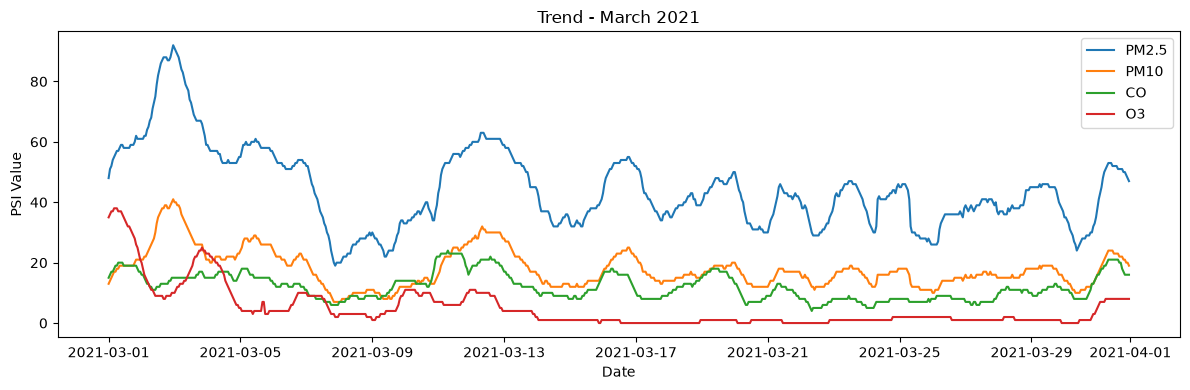

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/03-jogja-mar-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the March data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - March 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In March 2021, PM2.5 stayed the highest all month with several ups and downs (roughly 20–85), while PM10 and CO stayed low and close together most of the time, and O3 dropped to near zero in the second half of the month.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/03-jogja-mar-2021.csv


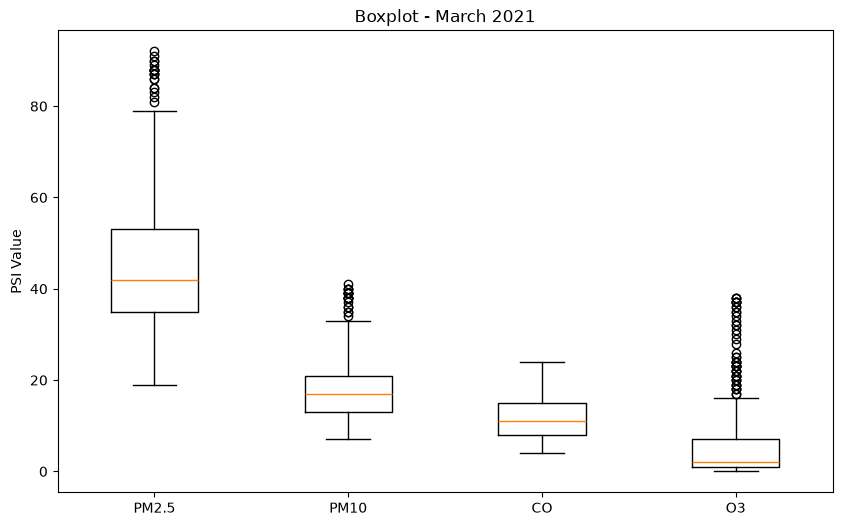

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - March 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

**In March 2021, PM2.5, PM10, and O3 all had high outliers (20, 20, and 51 points), with O3 having the highest, even though its median was low (2.0). CO had no outliers at all, and PM2.5 still had the highest median overall (42.0).**

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/03-jogja-mar-2021.csv


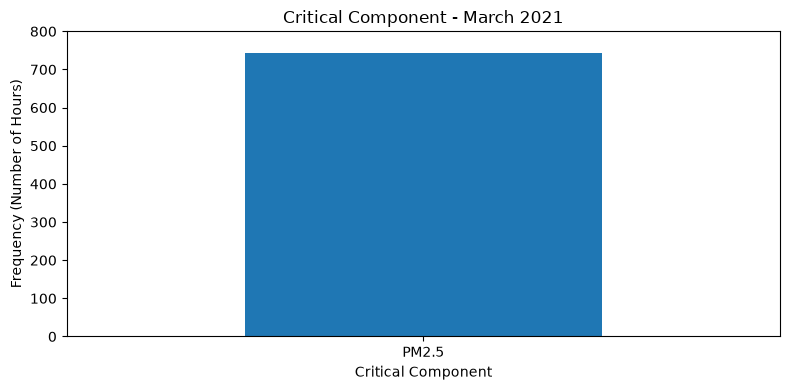

Critical Component
PM2.5    744
Name: count, dtype: int64

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")


plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - March 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  

**In March 2021, PM2.5 was the critical component for all 744 hours of the month, as no other pollutant (O3, CO, PM10, SO2) was ever the main driver of poor air quality.**

Data source: dataset/03-jogja-mar-2021.csv


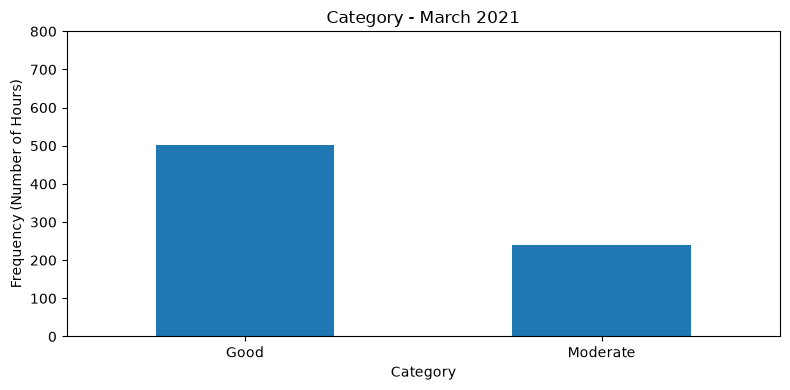

Category
Good        503
Moderate    241
Name: count, dtype: int64

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - March 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in April 2021**

In [35]:
import pandas as pd

df = pd.read_csv("dataset/04-jogja-apr-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM2.5,PM10,SO2,CO,O3,NO2,Max,Critical Component,Category
1,4/1/2021,00:00:00,45,19,21,15,8.0,3,21,PM2.5,Good
2,4/1/2021,01:00:00,44,18,20,14,8.0,3,20,PM2.5,Good
3,4/1/2021,02:00:00,43,17,20,14,7.0,3,20,PM2.5,Good
4,4/1/2021,03:00:00,40,17,20,13,7.0,3,20,PM2.5,Good
5,4/1/2021,04:00:00,38,16,19,12,7.0,3,19,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
716,4/30/2021,19:00:00,54,23,17,14,NaN,4,23,PM2.5,Good
717,4/30/2021,20:00:00,54,23,17,14,NaN,4,23,PM2.5,Good
718,4/30/2021,21:00:00,54,23,17,13,NaN,4,23,PM2.5,Good
719,4/30/2021,22:00:00,54,23,17,13,NaN,4,23,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [36]:
filename = "dataset/04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/04-jogja-apr-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                720 non-null    str    
 1   Time                720 non-null    str    
 2   PM2.5               720 non-null    int64  
 3   PM10                720 non-null    int64  
 4   SO2                 720 non-null    int64  
 5   CO                  720 non-null    int64  
 6   O3                  621 non-null    float64
 7   NO2                 720 non-null    int64  
 8   Max                 720 non-null    int64  
 9   Critical Component  720 non-null    str    
 10  Category            720 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 62.0 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [37]:
filename = "dataset/04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/04-jogja-apr-2021.csv


,PM2.5,PM10,SO2,CO,O3,NO2,Max
count,720.000000,720.000000,720.000000,720.000000,621.000000,720.000000,720.000000
mean,44.290278,18.830556,16.641667,11.547222,23.774557,3.848611,25.137500
std,10.556183,6.091482,3.306661,4.215409,9.962708,1.487312,8.569716
min,19.000000,8.000000,11.000000,5.000000,7.000000,2.000000,14.000000
25%,35.000000,14.000000,14.000000,9.000000,18.000000,3.000000,20.000000
50%,45.000000,18.000000,16.000000,11.000000,21.000000,3.000000,23.000000
75%,53.000000,23.000000,19.000000,13.000000,27.000000,5.000000,27.000000
max,66.000000,36.000000,28.000000,24.000000,65.000000,8.000000,65.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [38]:
filename = "dataset/04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/04-jogja-apr-2021.csv


Critical Component
PM2.5    91.666667
O3        8.333333
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [39]:
filename = "dataset/04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/04-jogja-apr-2021.csv


Category
Good        97.5
Moderate     2.5
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/04-jogja-apr-2021.csv


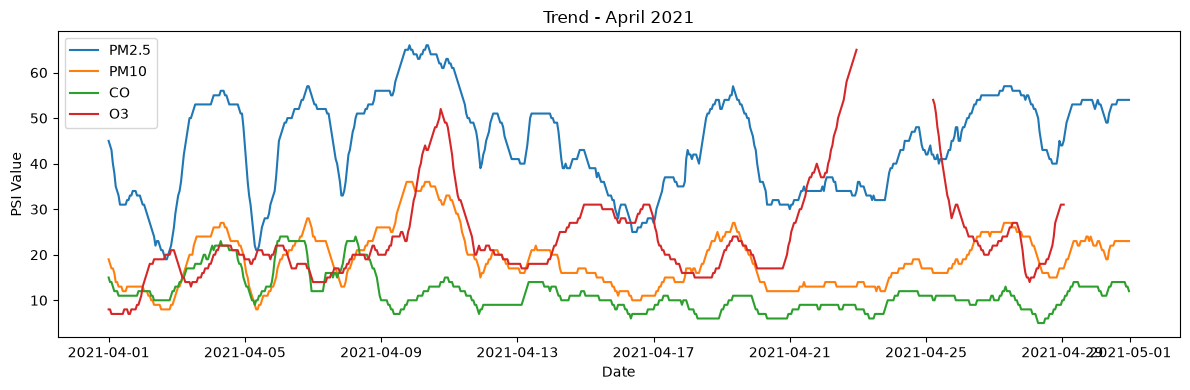

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/04-jogja-apr-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the April data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - April 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In April 2021, PM2.5 was still the highest most of the time (roughly 15-65), O3 spiked a few times sharply (like around April 9 and April 23) but stayed low in between, while PM10 and CO stayed low and fairly steady all month.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/04-jogja-apr-2021.csv


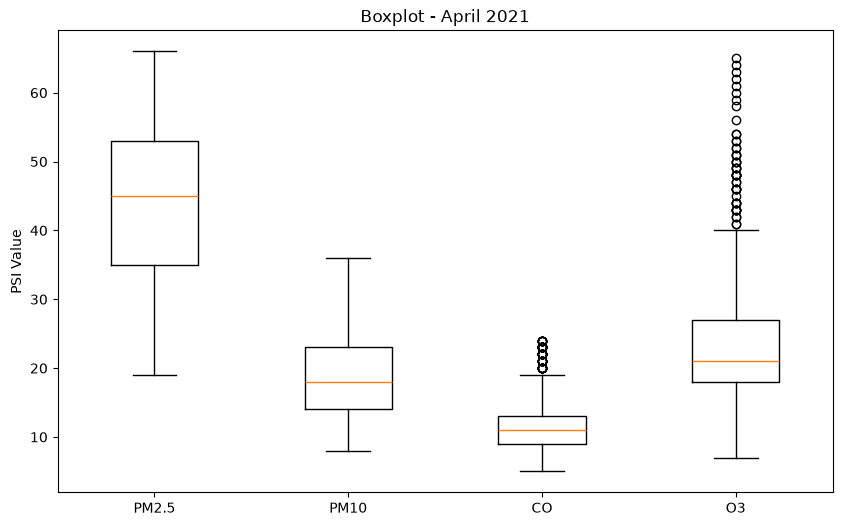

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - April 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/04-jogja-apr-2021.csv


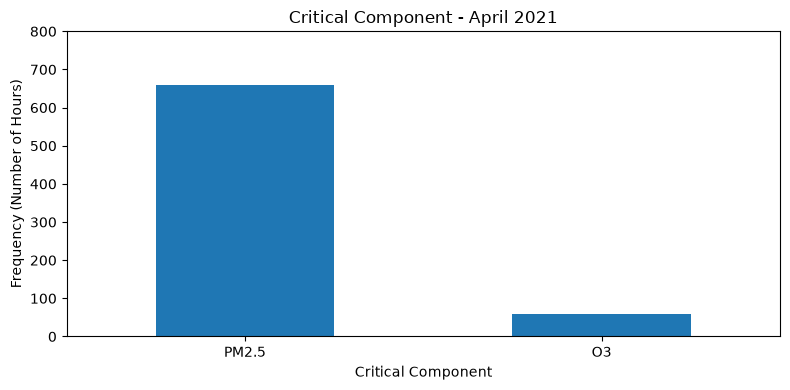

Critical Component
PM2.5    660
O3        60
Name: count, dtype: int64

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - April 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  # Display the counts for each bar of Critical Component

**In April 2021, PM2.5 was the critical component for the vast majority of the month (660 hours), while O3 only accounted for 60 hours, as no other pollutant was ever the main driver.**

Data source: dataset/04-jogja-apr-2021.csv


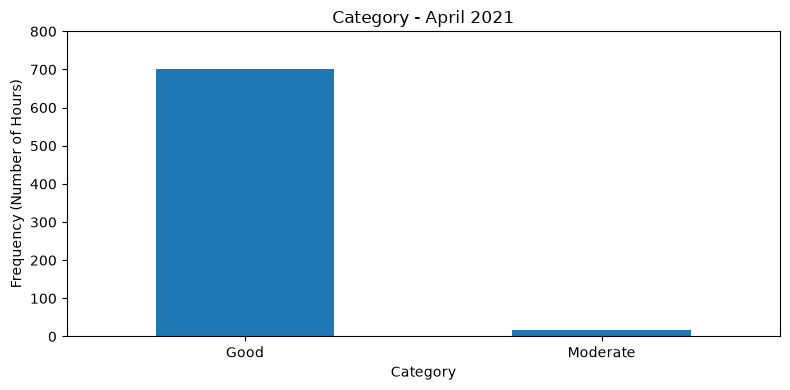

Category
Good        702
Moderate     18
Name: count, dtype: int64

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - April 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in May 2021**

In [44]:
import pandas as pd

df = pd.read_csv("dataset/05-jogja-may-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,5/1/2021,00:00:00,22,53,17,12,NaN,4,53,PM2.5,Moderate
2,5/1/2021,01:00:00,22,52,17,12,NaN,4,52,PM2.5,Moderate
3,5/1/2021,02:00:00,21,52,17,12,NaN,4,52,PM2.5,Moderate
4,5/1/2021,03:00:00,22,52,17,12,NaN,4,52,PM2.5,Moderate
5,5/1/2021,04:00:00,22,53,17,12,NaN,4,53,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
740,5/31/2021,19:00:00,21,50,19,9,21.0,6,50,PM2.5,Good
741,5/31/2021,20:00:00,21,50,20,9,19.0,6,50,PM2.5,Good
742,5/31/2021,21:00:00,20,50,20,9,17.0,5,50,PM2.5,Good
743,5/31/2021,22:00:00,20,49,20,8,15.0,5,49,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [45]:
filename = "dataset/05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/05-jogja-may-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                744 non-null    str    
 1   Time                744 non-null    str    
 2   PM10                744 non-null    int64  
 3   PM2.5               744 non-null    int64  
 4   SO2                 744 non-null    int64  
 5   CO                  744 non-null    int64  
 6   O3                  498 non-null    float64
 7   NO2                 744 non-null    int64  
 8   Max                 744 non-null    int64  
 9   Critical Component  744 non-null    str    
 10  Category            744 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [46]:
filename = "dataset/05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/05-jogja-may-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,744.000000,744.000000,744.000000,744.000000,498.000000,744.000000,744.000000
mean,24.138441,54.159946,17.251344,8.466398,35.524096,5.043011,54.422043
std,5.780733,5.873494,2.978613,2.949818,12.889736,1.125158,5.956265
min,13.000000,36.000000,11.000000,3.000000,10.000000,3.000000,36.000000
25%,20.000000,51.000000,15.000000,6.000000,24.000000,4.000000,51.000000
50%,22.000000,53.000000,18.000000,8.000000,37.000000,5.000000,54.000000
75%,28.000000,58.000000,20.000000,10.000000,46.000000,6.000000,59.000000
max,41.000000,69.000000,24.000000,18.000000,63.000000,8.000000,69.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [47]:
filename = "dataset/05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/05-jogja-may-2021.csv


Critical Component
PM2.5    95.430108
O3        4.569892
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [48]:
filename = "dataset/05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/05-jogja-may-2021.csv


Category
Moderate    77.956989
Good        22.043011
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/05-jogja-may-2021.csv


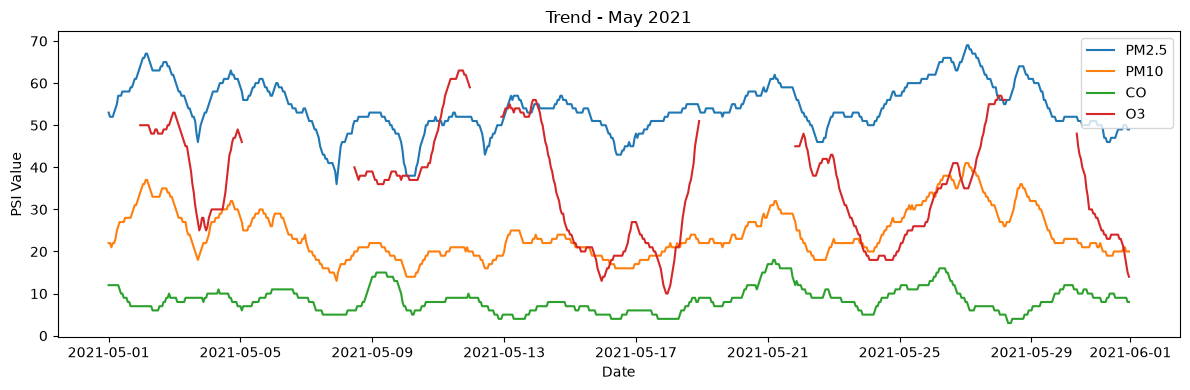

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/05-jogja-may-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the May data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - May 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In May 2021, PM2.5 stayed the highest most of the month (roughly 40-70), O3 swung wildly up and down with several sharp drops and spikes, and PM10 and CO stayed low and steady throughout.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/05-jogja-may-2021.csv


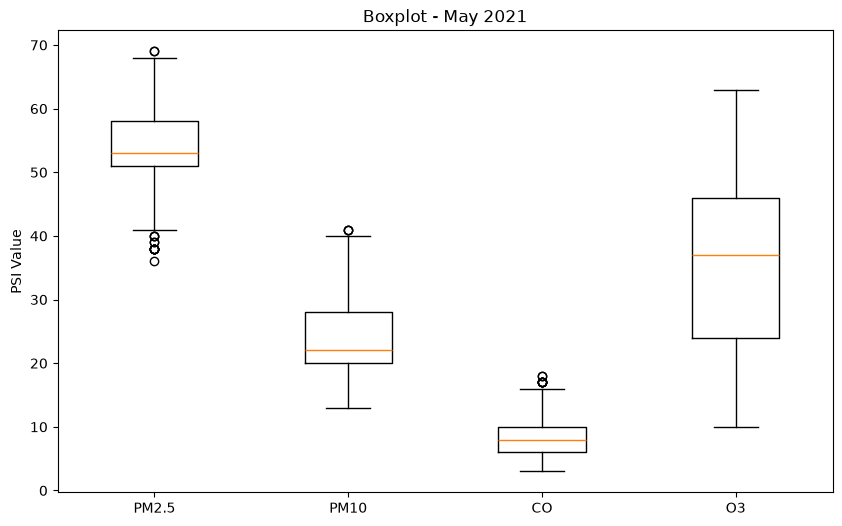

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - May 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/05-jogja-may-2021.csv


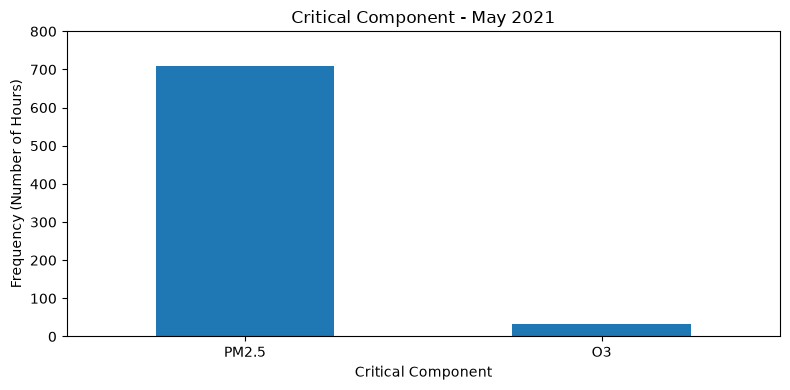

Critical Component
PM2.5    710
O3        34
Name: count, dtype: int64

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

# Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - May 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  # Display the counts for each bar of Critical Component

**In May 2021, PM2.5 was the critical component almost all month (710 hours), while O3 only briefly took over for 34 hours, as no other pollutant was ever the main driver.**

Data source: dataset/05-jogja-may-2021.csv


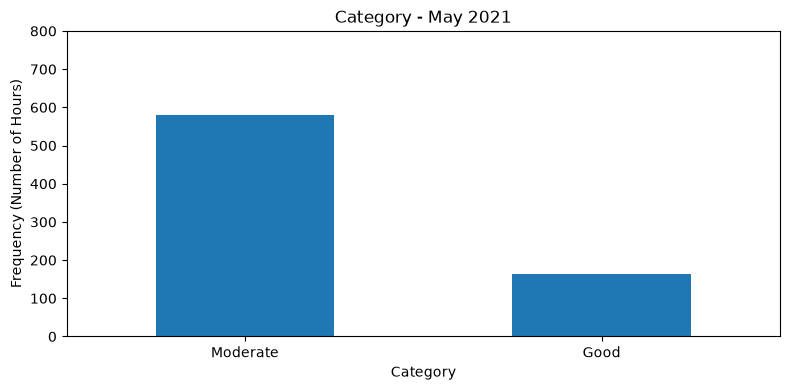

Category
Moderate    580
Good        164
Name: count, dtype: int64

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - May 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in June 2021**

In [53]:
import pandas as pd

df = pd.read_csv("dataset/06-jogja-jun-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,6/1/2021,00:00:00,20,48,21.0,8,14.0,5,48,PM2.5,Good
2,6/1/2021,01:00:00,20,49,21.0,8,14.0,5,49,PM2.5,Good
3,6/1/2021,02:00:00,21,50,21.0,8,14.0,5,50,PM2.5,Good
4,6/1/2021,03:00:00,21,51,21.0,9,15.0,5,51,PM2.5,Moderate
5,6/1/2021,04:00:00,22,51,22.0,9,16.0,5,51,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
716,6/30/2021,19:00:00,41,62,NaN,13,NaN,6,62,PM2.5,Moderate
717,6/30/2021,20:00:00,40,62,NaN,12,NaN,6,62,PM2.5,Moderate
718,6/30/2021,21:00:00,39,61,NaN,12,NaN,6,61,PM2.5,Moderate
719,6/30/2021,22:00:00,38,60,NaN,11,NaN,6,60,PM2.5,Moderate


#### <span style="color:blue">**Data Quality Check**</span>

In [54]:
filename = "dataset/06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/06-jogja-jun-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                720 non-null    str    
 1   Time                720 non-null    str    
 2   PM10                720 non-null    int64  
 3   PM2.5               720 non-null    int64  
 4   SO2                 118 non-null    float64
 5   CO                  720 non-null    int64  
 6   O3                  74 non-null     float64
 7   NO2                 720 non-null    int64  
 8   Max                 720 non-null    int64  
 9   Critical Component  720 non-null    str    
 10  Category            720 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 62.0 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [55]:
filename = "dataset/06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/06-jogja-jun-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,720.000000,720.000000,118.000000,720.000000,74.000000,720.000000,720.000000
mean,24.056944,50.343056,32.618644,10.869444,26.864865,6.159722,50.343056
std,11.447690,11.595540,20.116719,4.104973,10.432200,1.530693,11.595540
min,0.000000,17.000000,14.000000,3.000000,14.000000,3.000000,17.000000
25%,18.000000,42.000000,16.000000,7.000000,20.000000,5.000000,42.000000
50%,24.000000,51.000000,21.000000,11.000000,22.000000,6.000000,51.000000
75%,29.000000,56.000000,58.750000,13.000000,34.000000,7.000000,56.000000
max,52.000000,77.000000,64.000000,22.000000,49.000000,10.000000,77.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [56]:
filename = "dataset/06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/06-jogja-jun-2021.csv


Critical Component
PM2.5    100.0
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [57]:
filename = "dataset/06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/06-jogja-jun-2021.csv


Category
Moderate    55.972222
Good        44.027778
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/06-jogja-jun-2021.csv


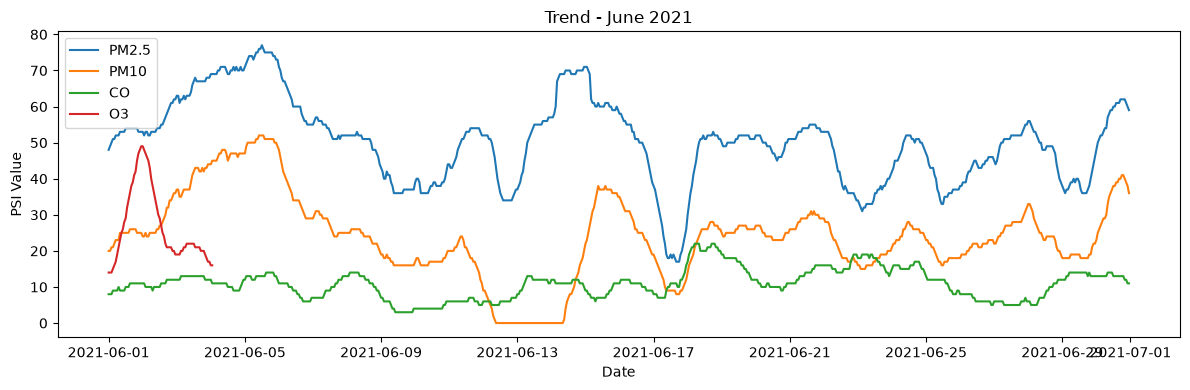

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/06-jogja-jun-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the June data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - June 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In June 2021, PM2.5 was still the highest most of the month (17–77), O3 only had data for the first week and then disappeared (missing for the rest of the month), while PM10 and CO stayed lower and moved together throughout.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/06-jogja-jun-2021.csv


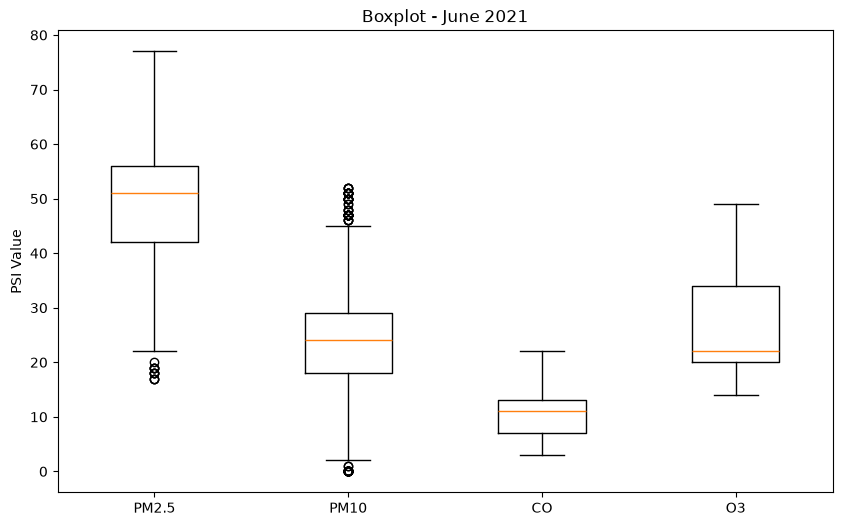

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - June 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/06-jogja-jun-2021.csv


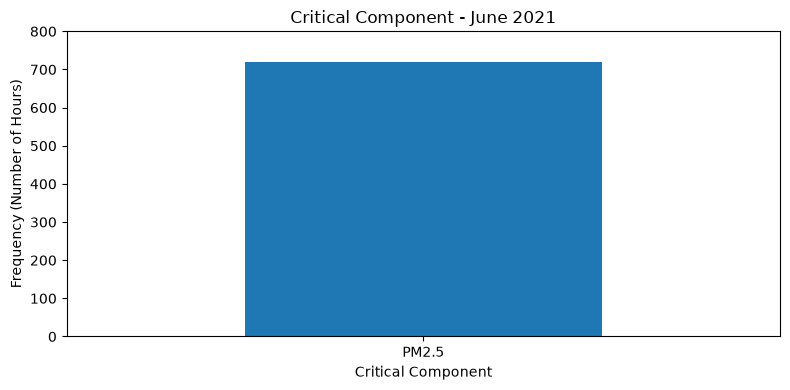

Critical Component
PM2.5    720
Name: count, dtype: int64

In [60]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

# Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - June 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()

**In June 2021, PM2.5 was the critical component for all 720 hours of the month, as no other pollutant was ever the main driver, the same pattern as March.**

Data source: dataset/06-jogja-jun-2021.csv


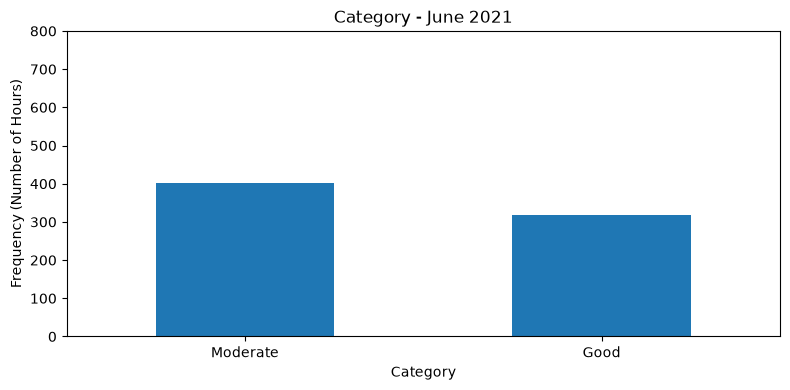

Category
Moderate    403
Good        317
Name: count, dtype: int64

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - June 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in July 2021**

In [62]:
import pandas as pd

df = pd.read_csv("dataset/07-jogja-jul-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,7/1/2021,00:00:00,35.0,58.0,NaN,11.0,NaN,5.0,58,PM2.5,Moderate
2,7/1/2021,01:00:00,34.0,57.0,NaN,10.0,NaN,5.0,57,PM2.5,Moderate
3,7/1/2021,02:00:00,33.0,57.0,NaN,10.0,NaN,5.0,57,PM2.5,Moderate
4,7/1/2021,03:00:00,32.0,56.0,NaN,10.0,NaN,5.0,56,PM2.5,Moderate
5,7/1/2021,04:00:00,31.0,55.0,NaN,9.0,NaN,5.0,55,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
740,7/31/2021,19:00:00,11.0,25.0,NaN,1.0,NaN,2.0,25,PM2.5,Good
741,7/31/2021,20:00:00,11.0,24.0,NaN,1.0,NaN,2.0,24,PM2.5,Good
742,7/31/2021,21:00:00,11.0,24.0,NaN,1.0,NaN,2.0,24,PM2.5,Good
743,7/31/2021,22:00:00,10.0,24.0,NaN,1.0,NaN,2.0,24,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [63]:
filename = "dataset/07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/07-jogja-jul-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                744 non-null    str    
 1   Time                744 non-null    str    
 2   PM10                700 non-null    float64
 3   PM2.5               700 non-null    float64
 4   SO2                 0 non-null      float64
 5   CO                  700 non-null    float64
 6   O3                  0 non-null      float64
 7   NO2                 700 non-null    float64
 8   Max                 744 non-null    int64  
 9   Critical Component  700 non-null    str    
 10  Category            744 non-null    str    
dtypes: float64(6), int64(1), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [64]:
filename = "dataset/07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/07-jogja-jul-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,700.000000,700.000000,0.0,700.000000,0.0,700.000000,744.000000
mean,21.142857,43.208571,NaN,6.338571,NaN,3.485714,40.653226
std,5.388181,8.326797,NaN,3.145212,NaN,0.829410,13.009704
min,10.000000,24.000000,NaN,1.000000,NaN,1.000000,0.000000
25%,17.000000,36.000000,NaN,4.000000,NaN,3.000000,35.000000
50%,21.000000,43.000000,NaN,6.000000,NaN,3.000000,43.000000
75%,25.000000,51.000000,NaN,9.000000,NaN,4.000000,51.000000
max,35.000000,58.000000,NaN,14.000000,NaN,5.000000,58.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [65]:
filename = "dataset/07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/07-jogja-jul-2021.csv


Critical Component
PM2.5    100.0
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [66]:
filename = "dataset/07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/07-jogja-jul-2021.csv


Category
Good        74.731183
Moderate    25.268817
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/07-jogja-jul-2021.csv


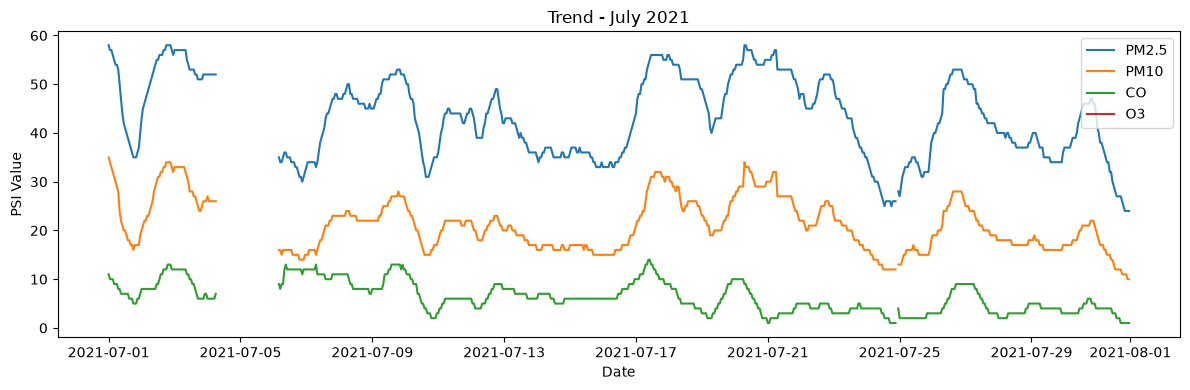

In [67]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/07-jogja-jul-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the July data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - July 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/07-jogja-jul-2021.csv


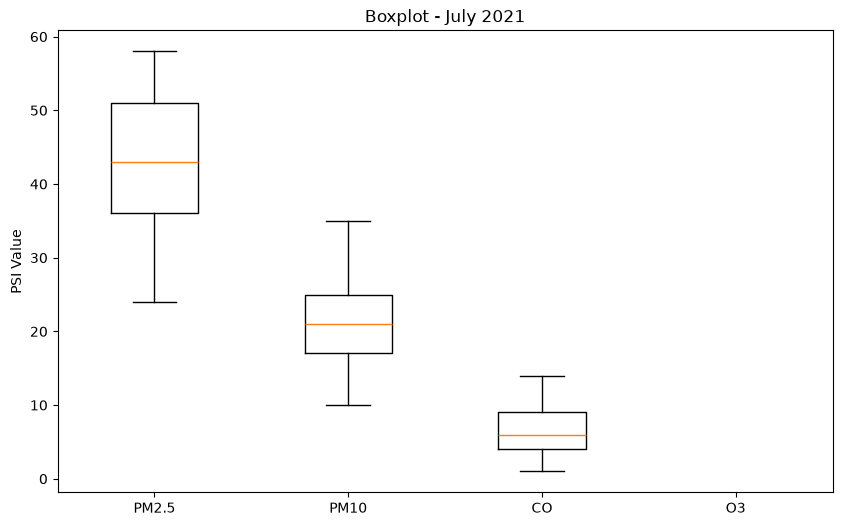

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - July 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

In [69]:
print(df.shape)
print(df.columns.tolist())
print(df[numeric_cols].isna().sum())
print(df[numeric_cols].describe())

(744, 11)
['Date', 'Time', 'PM10', 'PM2.5', 'SO2', 'CO', 'O3', 'NO2', 'Max', 'Critical Component', 'Category']
PM2.5     44
PM10      44
CO        44
O3       744
dtype: int64
            PM2.5        PM10          CO   O3
count  700.000000  700.000000  700.000000  0.0
mean    43.208571   21.142857    6.338571  NaN
std      8.326797    5.388181    3.145212  NaN
min     24.000000   10.000000    1.000000  NaN
25%     36.000000   17.000000    4.000000  NaN
50%     43.000000   21.000000    6.000000  NaN
75%     51.000000   25.000000    9.000000  NaN
max     58.000000   35.000000   14.000000  NaN


##### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/07-jogja-jul-2021.csv


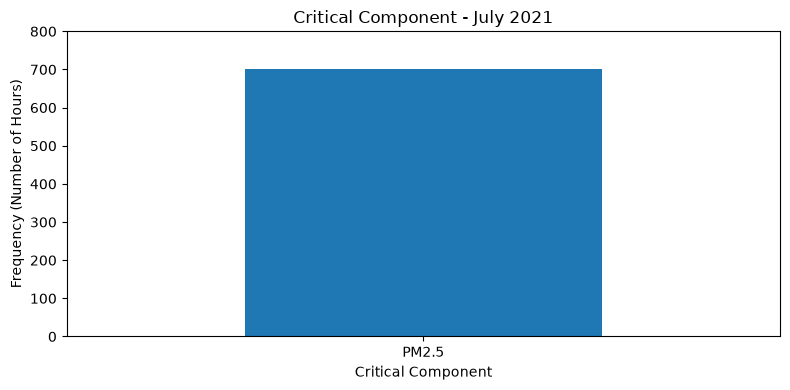

Critical Component
PM2.5    700
Name: count, dtype: int64

In [70]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - July 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: dataset/07-jogja-jul-2021.csv


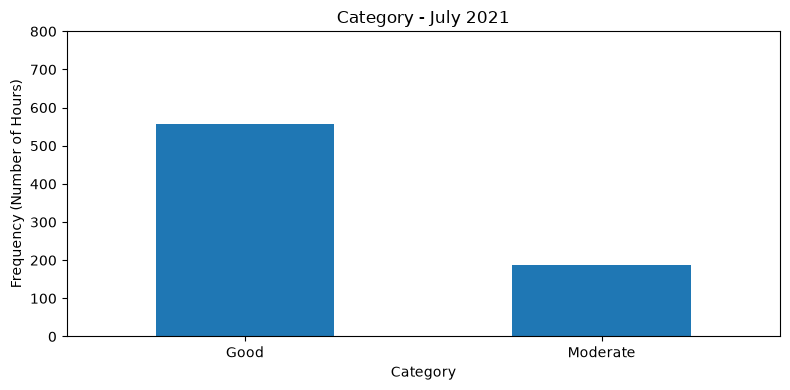

Category
Good        556
Moderate    188
Name: count, dtype: int64

In [71]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - July 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in August 2021**

In [72]:
import pandas as pd

df = pd.read_csv("dataset/08-jogja-aug-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,8/1/2021,00:00:00,10.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
2,8/1/2021,01:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
3,8/1/2021,02:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
4,8/1/2021,03:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
5,8/1/2021,04:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,8/31/2021,19:00:00,16.0,31.0,NaN,9.0,NaN,3.0,31,PM2.5,Good
741,8/31/2021,20:00:00,16.0,31.0,NaN,9.0,NaN,3.0,31,PM2.5,Good
742,8/31/2021,21:00:00,16.0,31.0,NaN,9.0,NaN,3.0,31,PM2.5,Good
743,8/31/2021,22:00:00,16.0,32.0,NaN,9.0,NaN,3.0,32,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [12]:
filename = "dataset/08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/08-jogja-aug-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                744 non-null    str    
 1   Time                744 non-null    str    
 2   PM10                723 non-null    float64
 3   PM2.5               723 non-null    float64
 4   SO2                 0 non-null      float64
 5   CO                  723 non-null    float64
 6   O3                  0 non-null      float64
 7   NO2                 723 non-null    float64
 8   Max                 744 non-null    int64  
 9   Critical Component  723 non-null    str    
 10  Category            744 non-null    str    
dtypes: float64(6), int64(1), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [13]:
filename = "dataset/08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/08-jogja-aug-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,723.000000,723.000000,0.0,723.000000,0.0,723.000000,744.000000
mean,16.333333,32.390041,NaN,3.795297,NaN,2.800830,31.475806
std,7.437893,11.635270,NaN,2.794857,NaN,0.675367,12.663656
min,6.000000,14.000000,NaN,0.000000,NaN,1.000000,0.000000
25%,11.000000,23.000000,NaN,1.000000,NaN,2.000000,23.000000
50%,15.000000,30.000000,NaN,3.000000,NaN,3.000000,30.000000
75%,19.000000,38.000000,NaN,5.000000,NaN,3.000000,38.000000
max,48.000000,68.000000,NaN,12.000000,NaN,5.000000,68.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [75]:
filename = "dataset/08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/08-jogja-aug-2021.csv


Critical Component
PM2.5    100.0
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [76]:
filename = "dataset/08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/08-jogja-aug-2021.csv


Category
Good        89.247312
Moderate    10.752688
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/08-jogja-aug-2021.csv


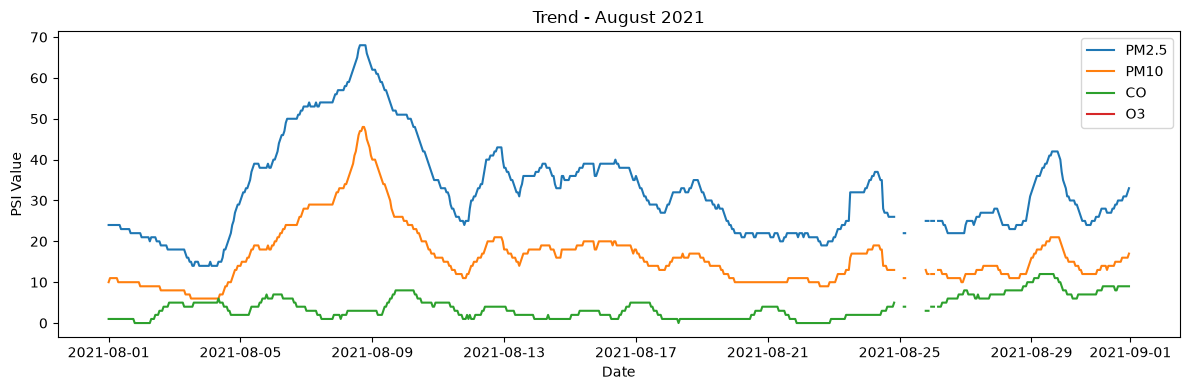

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/08-jogja-aug-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the July data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - August 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/08-jogja-aug-2021.csv


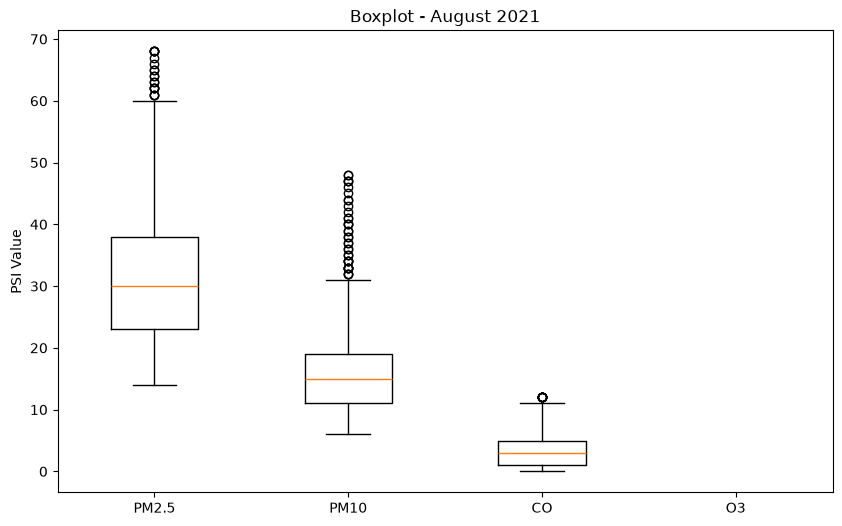

In [78]:
# ===== Agustus 2021 =====
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - August 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/08-jogja-aug-2021.csv


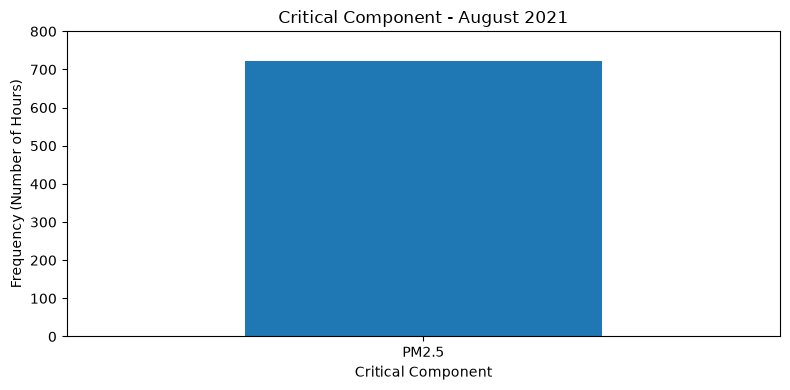

Critical Component
PM2.5    723
Name: count, dtype: int64

In [79]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - August 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: dataset/08-jogja-aug-2021.csv


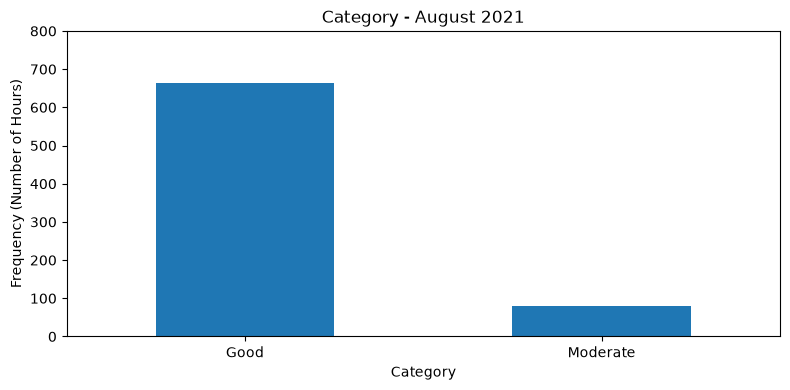

Category
Good        664
Moderate     80
Name: count, dtype: int64

In [80]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - August 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in September 2021**

In [81]:
import pandas as pd

df = pd.read_csv("dataset/09-jogja-sep-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,9/1/2021,00:00:00,16.0,28.0,0.0,7.0,0.0,4.0,28,PM2.5,Good
2,9/1/2021,01:00:00,16.0,28.0,0.0,7.0,0.0,4.0,28,PM2.5,Good
3,9/1/2021,02:00:00,16.0,28.0,0.0,7.0,0.0,4.0,28,PM2.5,Good
4,9/1/2021,03:00:00,18.0,32.0,0.0,7.0,1.0,4.0,32,PM2.5,Good
5,9/1/2021,04:00:00,18.0,32.0,0.0,6.0,1.0,4.0,32,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
716,9/30/2021,19:00:00,19.0,35.0,0.0,7.0,4.0,4.0,35,PM2.5,Good
717,9/30/2021,20:00:00,19.0,35.0,0.0,7.0,4.0,4.0,35,PM2.5,Good
718,9/30/2021,21:00:00,19.0,36.0,0.0,7.0,5.0,4.0,36,PM2.5,Good
719,9/30/2021,22:00:00,20.0,36.0,0.0,7.0,5.0,4.0,36,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [14]:
filename = "dataset/09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/09-jogja-sep-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                720 non-null    str    
 1   Time                720 non-null    str    
 2   PM10                719 non-null    float64
 3   PM2.5               719 non-null    float64
 4   SO2                 517 non-null    float64
 5   CO                  719 non-null    float64
 6   O3                  499 non-null    float64
 7   NO2                 719 non-null    float64
 8   Max                 720 non-null    int64  
 9   Critical Component  719 non-null    str    
 10  Category            720 non-null    str    
dtypes: float64(6), int64(1), str(4)
memory usage: 62.0 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [15]:
filename = "dataset/09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/09-jogja-sep-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,719.000000,719.000000,517.000000,719.000000,499.000000,719.000000,720.000000
mean,15.425591,29.208623,9.684720,8.180807,12.611222,4.853964,31.756944
std,3.888733,6.673306,19.065554,1.838347,13.114003,1.504712,10.292824
min,8.000000,14.000000,0.000000,4.000000,0.000000,2.000000,0.000000
25%,12.000000,24.000000,0.000000,7.000000,2.000000,4.000000,24.000000
50%,16.000000,29.000000,1.000000,8.000000,8.000000,5.000000,30.000000
75%,19.000000,35.000000,5.000000,9.000000,20.000000,6.000000,37.000000
max,24.000000,44.000000,63.000000,14.000000,52.000000,8.000000,63.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [84]:
filename = "dataset/09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/09-jogja-sep-2021.csv


Critical Component
PM2.5    86.509040
SO2      11.543811
O3        1.947149
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [85]:
filename = "dataset/09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/09-jogja-sep-2021.csv


Category
Good        92.638889
Moderate     7.361111
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/09-jogja-sep-2021.csv


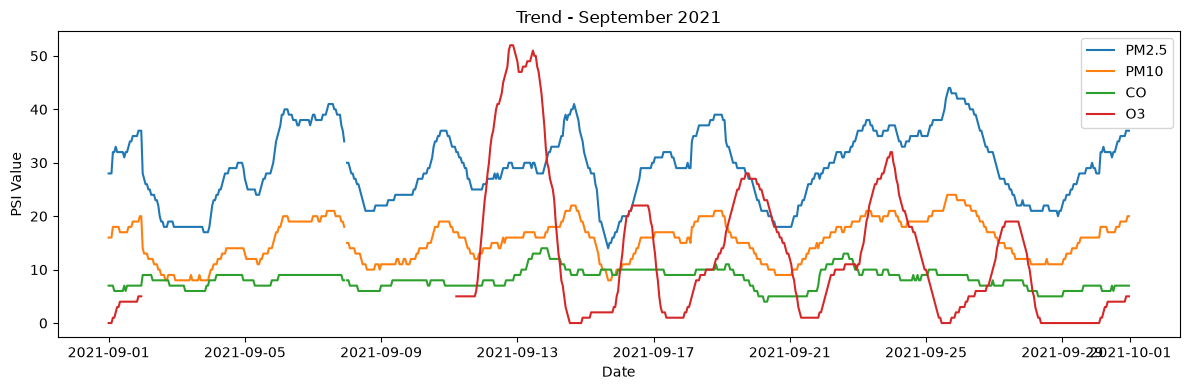

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/09-jogja-sep-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the July data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - September 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/09-jogja-sep-2021.csv


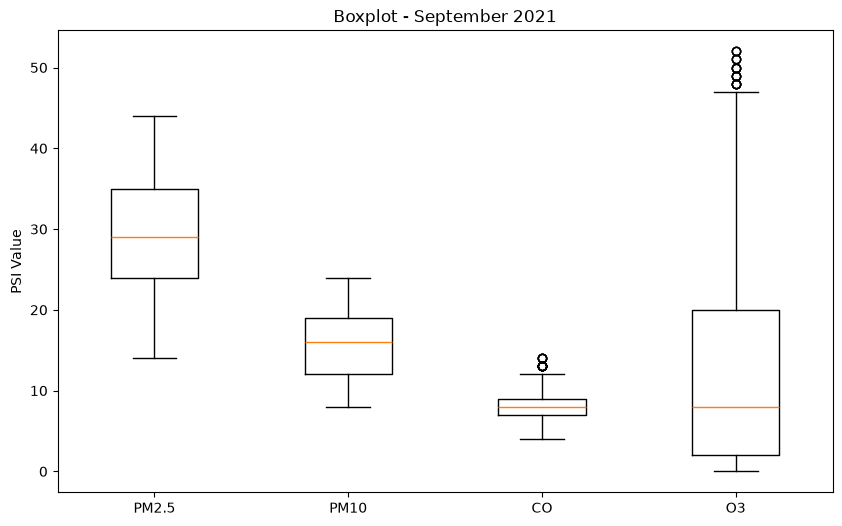

In [87]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - September 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/09-jogja-sep-2021.csv


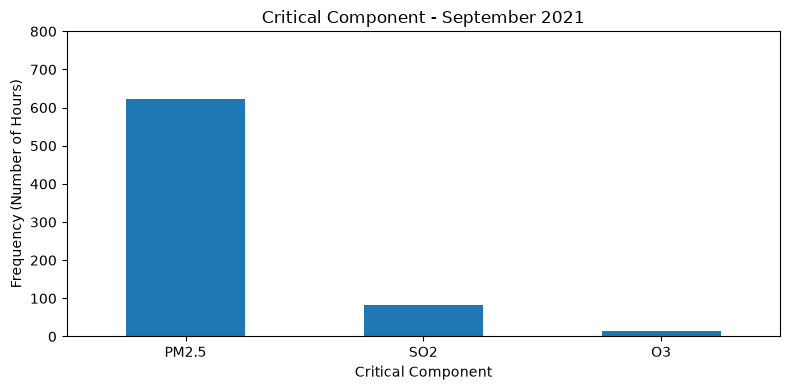

Critical Component
PM2.5    622
SO2       83
O3        14
Name: count, dtype: int64

In [88]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - September 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: dataset/09-jogja-sep-2021.csv


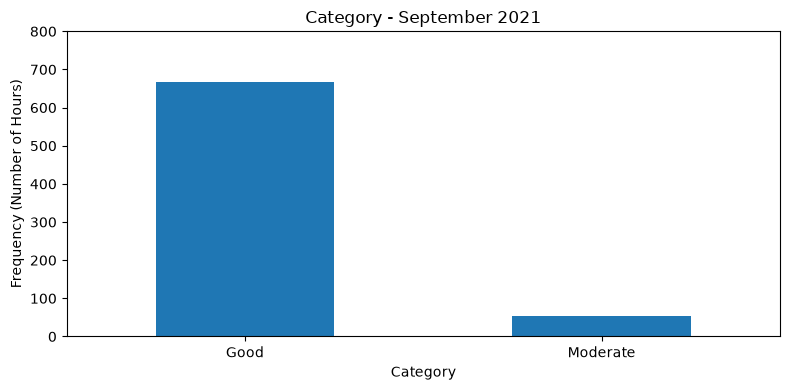

Category
Good        667
Moderate     53
Name: count, dtype: int64

In [89]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - September 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in October 2021**

In [90]:
import pandas as pd

df = pd.read_csv("dataset/10-jogja-oct-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,10/1/2021,00:00:00,19.0,35.0,0.0,7.0,5.0,4.0,35,PM2.5,Good
2,10/1/2021,01:00:00,19.0,35.0,0.0,7.0,5.0,4.0,35,PM2.5,Good
3,10/1/2021,02:00:00,18.0,34.0,0.0,7.0,6.0,4.0,34,PM2.5,Good
4,10/1/2021,03:00:00,16.0,30.0,0.0,7.0,7.0,4.0,30,PM2.5,Good
5,10/1/2021,04:00:00,16.0,30.0,0.0,7.0,8.0,4.0,30,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,10/31/2021,19:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
741,10/31/2021,20:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
742,10/31/2021,21:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
743,10/31/2021,22:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [16]:
filename = "dataset/10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/10-jogja-oct-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                744 non-null    str    
 1   Time                744 non-null    str    
 2   PM10                741 non-null    float64
 3   PM2.5               741 non-null    float64
 4   SO2                 741 non-null    float64
 5   CO                  741 non-null    float64
 6   O3                  675 non-null    float64
 7   NO2                 741 non-null    float64
 8   Max                 744 non-null    int64  
 9   Critical Component  741 non-null    str    
 10  Category            744 non-null    str    
dtypes: float64(6), int64(1), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [17]:
filename = "dataset/10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/10-jogja-oct-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,741.000000,741.000000,741.000000,741.000000,675.000000,741.000000,744.000000
mean,13.167341,24.009447,5.834008,7.932524,17.642963,4.242915,29.498656
std,3.191892,5.218591,7.817391,3.253403,19.486926,1.480630,12.124078
min,7.000000,13.000000,0.000000,4.000000,0.000000,0.000000,0.000000
25%,11.000000,20.000000,0.000000,6.000000,3.000000,4.000000,22.000000
50%,13.000000,23.000000,2.000000,7.000000,10.000000,4.000000,25.000000
75%,15.000000,28.000000,9.000000,9.000000,26.500000,5.000000,32.000000
max,23.000000,41.000000,27.000000,16.000000,69.000000,7.000000,69.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [18]:
filename = "dataset/10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/10-jogja-oct-2021.csv


Critical Component
PM2.5    69.635628
O3       27.125506
SO2       3.238866
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [19]:
filename = "dataset/10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/10-jogja-oct-2021.csv


Category
Good        90.053763
Moderate     9.946237
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/10-jogja-oct-2021.csv


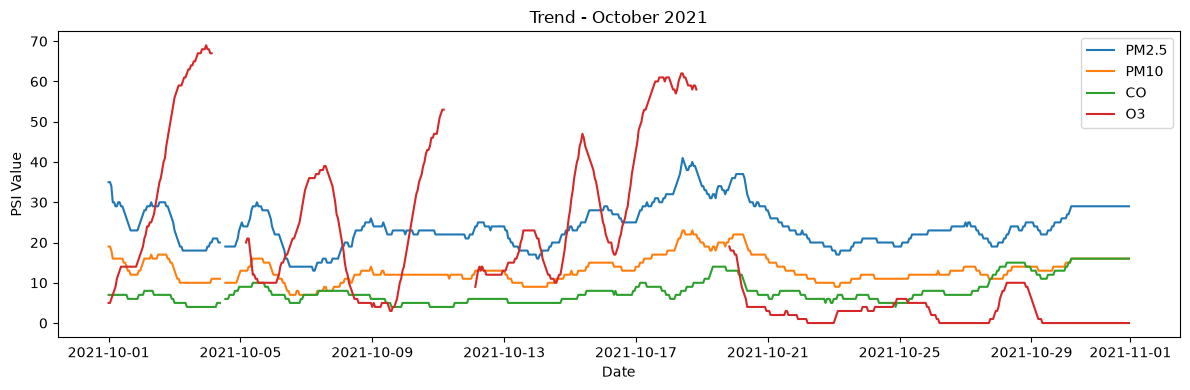

In [95]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/10-jogja-oct-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the October data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - October 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/10-jogja-oct-2021.csv


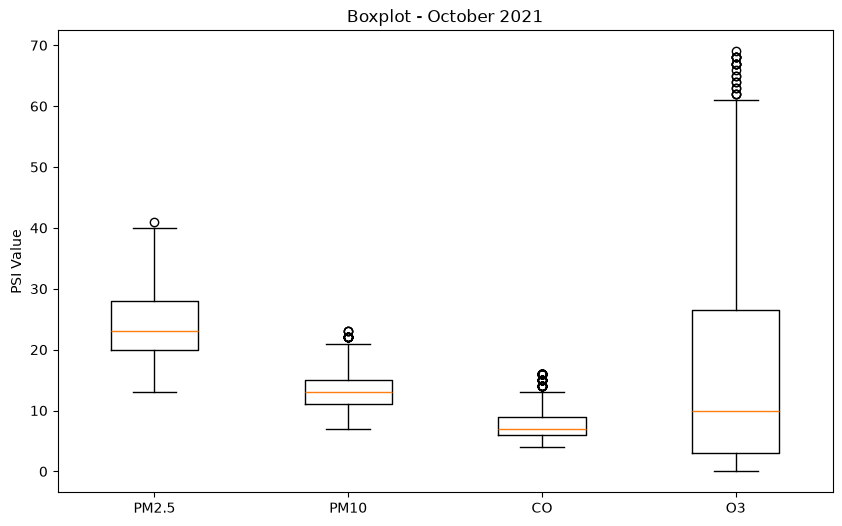

In [96]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - October 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/10-jogja-oct-2021.csv


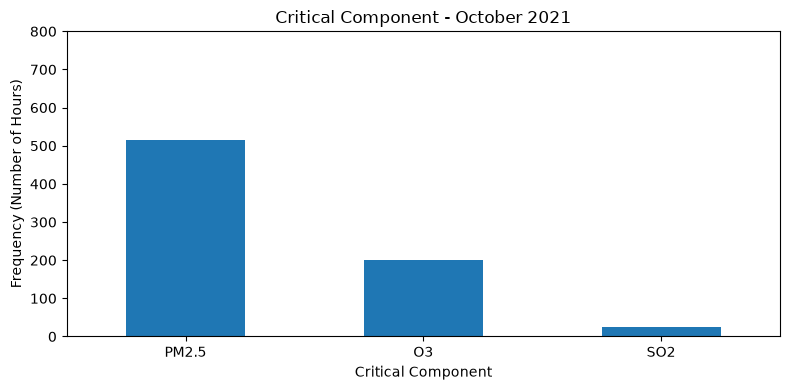

Critical Component
PM2.5    516
O3       201
SO2       24
Name: count, dtype: int64

In [97]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - October 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: dataset/10-jogja-oct-2021.csv


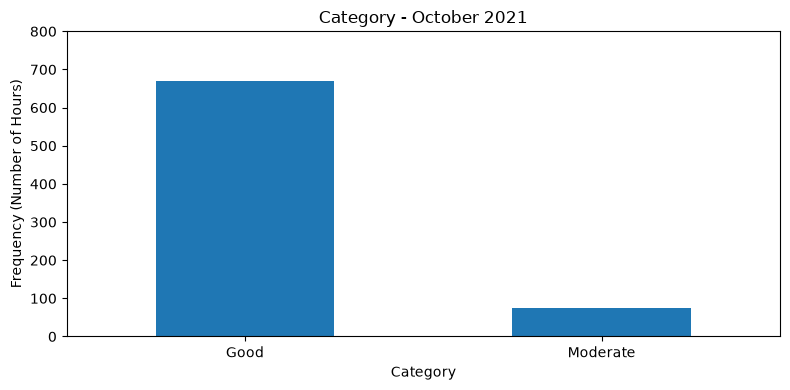

Category
Good        670
Moderate     74
Name: count, dtype: int64

In [98]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - October 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in November 2021**

In [99]:
import pandas as pd

df = pd.read_csv("dataset/11-jogja-nov-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,11/1/2021,00:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
2,11/1/2021,01:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
3,11/1/2021,02:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
4,11/1/2021,03:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
5,11/1/2021,04:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
716,11/30/2021,19:00:00,45.0,53.0,27.0,20.0,33.0,0.0,53,PM2.5,Moderate
717,11/30/2021,20:00:00,45.0,53.0,27.0,20.0,33.0,0.0,53,PM2.5,Moderate
718,11/30/2021,21:00:00,43.0,51.0,26.0,20.0,34.0,0.0,51,PM2.5,Moderate
719,11/30/2021,22:00:00,37.0,47.0,26.0,19.0,35.0,0.0,47,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [20]:
filename = "dataset/11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/11-jogja-nov-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                720 non-null    str    
 1   Time                720 non-null    str    
 2   PM10                658 non-null    float64
 3   PM2.5               658 non-null    float64
 4   SO2                 601 non-null    float64
 5   CO                  657 non-null    float64
 6   O3                  652 non-null    float64
 7   NO2                 657 non-null    float64
 8   Max                 720 non-null    int64  
 9   Critical Component  658 non-null    str    
 10  Category            720 non-null    str    
dtypes: float64(6), int64(1), str(4)
memory usage: 62.0 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [21]:
filename = "dataset/11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/11-jogja-nov-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,658.000000,658.000000,601.000000,657.000000,652.000000,657.000000,720.000000
mean,13.109422,23.115502,12.836938,18.138508,25.237730,3.143075,34.793056
std,8.347305,11.009420,17.874191,5.213783,19.540031,2.290806,16.229413
min,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,8.000000,16.000000,0.000000,15.000000,1.000000,1.000000,25.000000
50%,11.000000,21.000000,0.000000,19.000000,27.000000,2.000000,35.000000
75%,15.000000,27.000000,30.000000,22.000000,38.000000,5.000000,45.000000
max,45.000000,57.000000,51.000000,28.000000,77.000000,10.000000,77.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [102]:
filename = "dataset/11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/11-jogja-nov-2021.csv


Critical Component
PM2.5    41.793313
O3       39.209726
SO2      17.021277
CO        1.975684
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [103]:
filename = "dataset/11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/11-jogja-nov-2021.csv


Category
Good        86.805556
Moderate    13.194444
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/11-jogja-nov-2021.csv


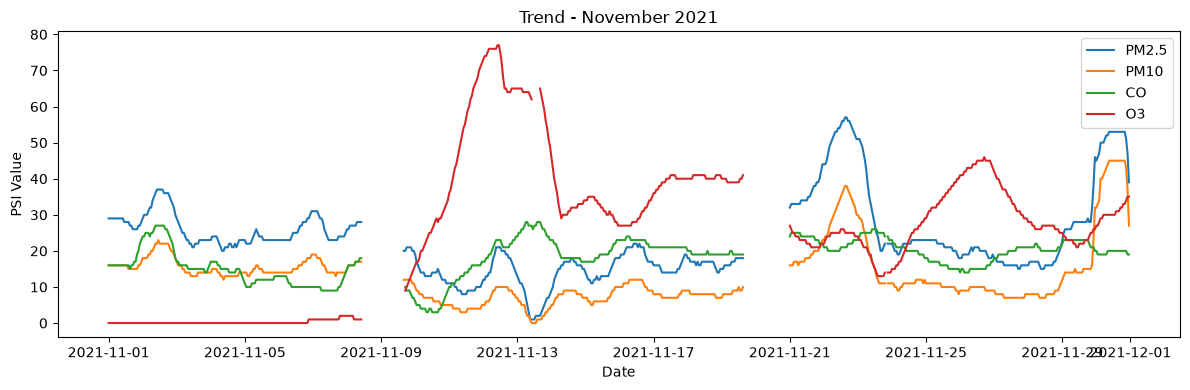

In [104]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/11-jogja-nov-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the October data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - November 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/11-jogja-nov-2021.csv


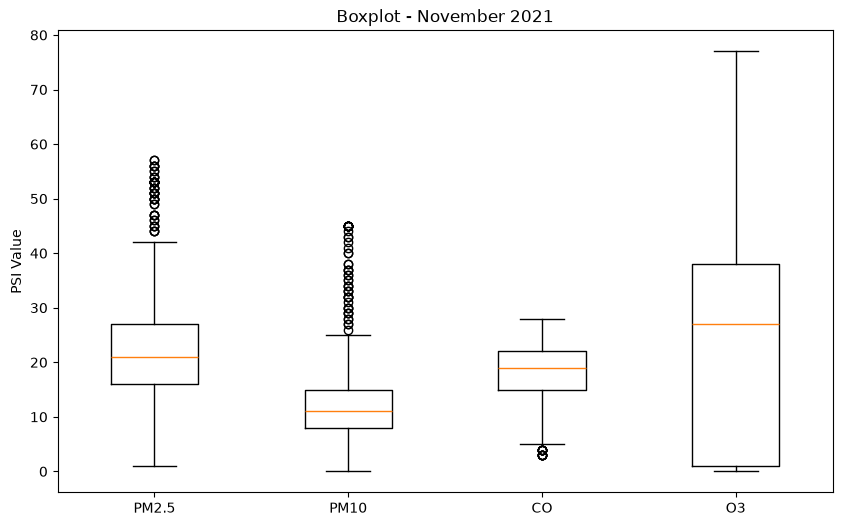

In [105]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - November 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/11-jogja-nov-2021.csv


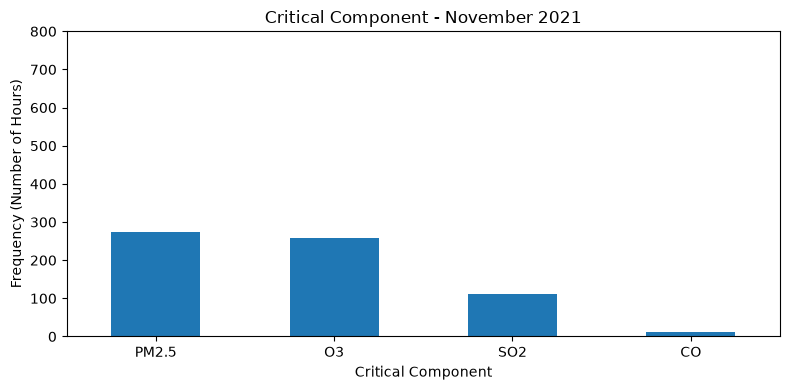

Critical Component
PM2.5    275
O3       258
SO2      112
CO        13
Name: count, dtype: int64

In [106]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - November 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: dataset/11-jogja-nov-2021.csv


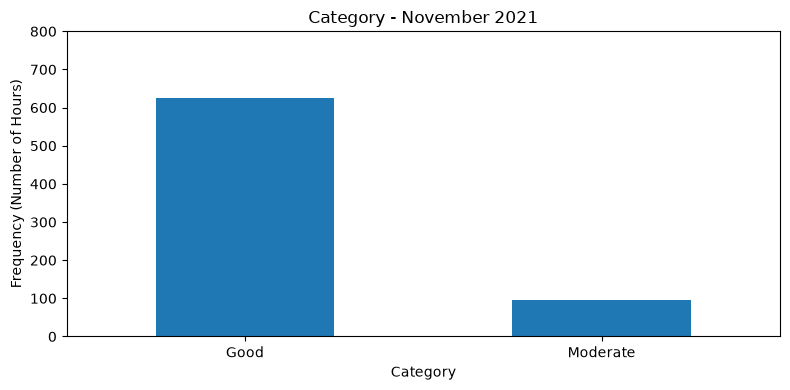

Category
Good        625
Moderate     95
Name: count, dtype: int64

In [107]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - November 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in December 2021**

In [108]:
import pandas as pd

df = pd.read_csv("dataset/12-jogja-dec-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,12/1/2021,00:00:00,26.0,38.0,25.0,19.0,36.0,0.0,38,PM2.5,Good
2,12/1/2021,01:00:00,24.0,36.0,24.0,18.0,37.0,0.0,37,O3,Good
3,12/1/2021,02:00:00,23.0,34.0,23.0,18.0,38.0,0.0,38,O3,Good
4,12/1/2021,03:00:00,18.0,31.0,23.0,17.0,39.0,0.0,39,O3,Good
5,12/1/2021,04:00:00,17.0,31.0,22.0,17.0,40.0,0.0,40,O3,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,12/31/2021,19:00:00,15.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good
741,12/31/2021,20:00:00,16.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good
742,12/31/2021,21:00:00,17.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good
743,12/31/2021,22:00:00,18.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [22]:
filename = "dataset/12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: dataset/12-jogja-dec-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                744 non-null    str    
 1   Time                744 non-null    str    
 2   PM10                642 non-null    float64
 3   PM2.5               642 non-null    float64
 4   SO2                 642 non-null    float64
 5   CO                  642 non-null    float64
 6   O3                  642 non-null    float64
 7   NO2                 642 non-null    float64
 8   Max                 744 non-null    int64  
 9   Critical Component  642 non-null    str    
 10  Category            744 non-null    str    
dtypes: float64(6), int64(1), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [23]:
filename = "dataset/12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: dataset/12-jogja-dec-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,744.000000
mean,18.478193,1.805296,12.147975,19.327103,8.862928,6.386293,20.919355
std,8.705638,6.643902,6.074029,2.783758,12.160647,4.800578,11.160228
min,8.000000,0.000000,1.000000,14.000000,0.000000,0.000000,0.000000
25%,13.000000,0.000000,8.000000,17.000000,1.000000,1.000000,18.000000
50%,17.000000,0.000000,11.000000,19.000000,3.000000,10.000000,20.000000
75%,19.750000,0.000000,17.000000,21.000000,9.000000,11.000000,26.000000
max,51.000000,38.000000,25.000000,26.000000,45.000000,12.000000,51.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [111]:
filename = "dataset/12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/12-jogja-dec-2021.csv


Critical Component
CO       59.034268
PM10     28.504673
O3       12.305296
PM2.5     0.155763
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [112]:
filename = "dataset/12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: dataset/12-jogja-dec-2021.csv


Category
Good        99.596774
Moderate     0.403226
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

#### <span style="color:blue">**1. Line Graph**</span>

Data source: dataset/12-jogja-dec-2021.csv


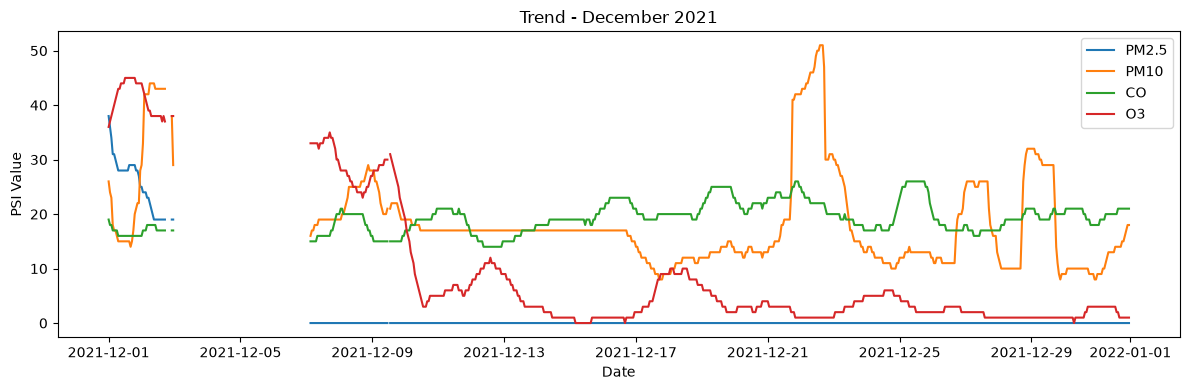

In [113]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/12-jogja-dec-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the October data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - December 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

#### <span style="color:blue">**2. Boxplot**</span>

Data source: dataset/12-jogja-dec-2021.csv


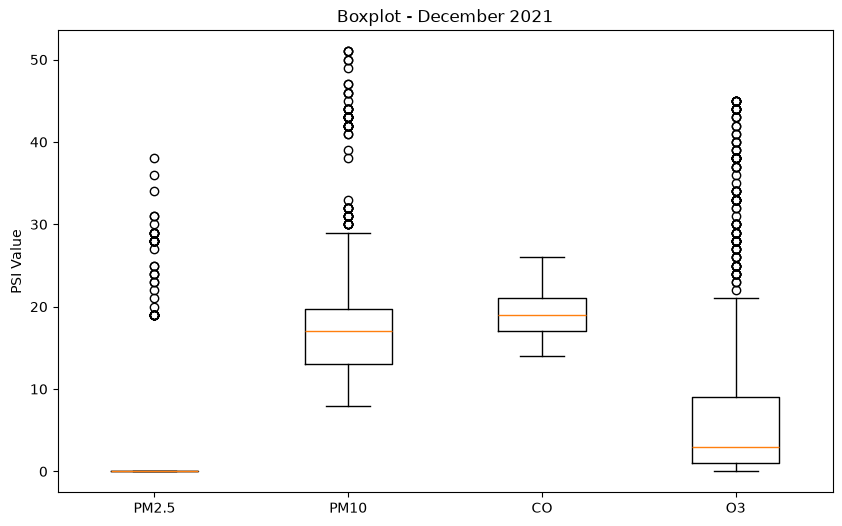

In [114]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - December 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

#### <span style="color:blue">**3. Bar Chart**</span>

Data source: dataset/12-jogja-dec-2021.csv


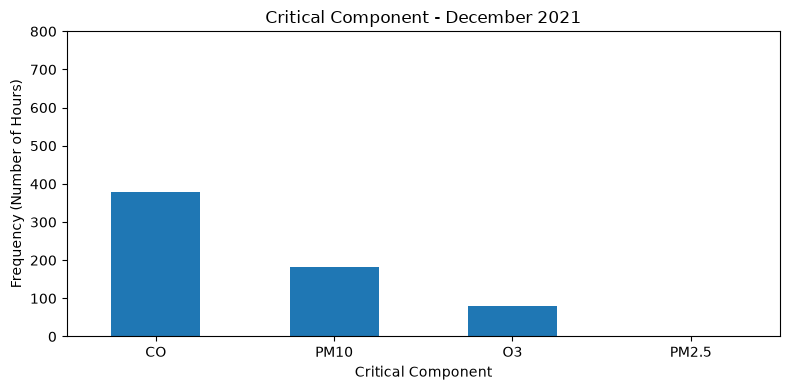

Critical Component
CO       379
PM10     183
O3        79
PM2.5      1
Name: count, dtype: int64

In [115]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - December 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: dataset/12-jogja-dec-2021.csv


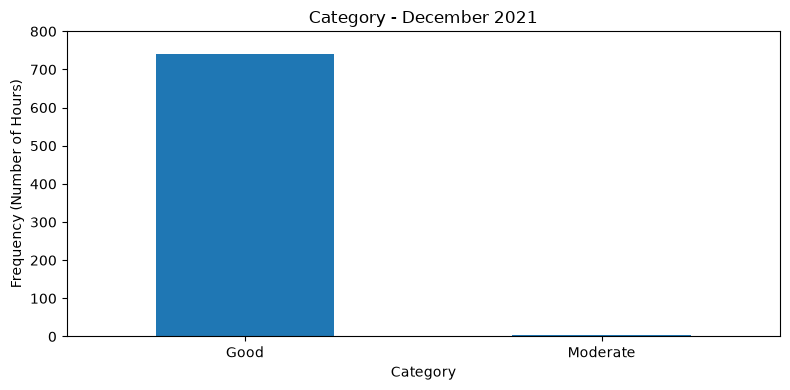

Category
Good        741
Moderate      3
Name: count, dtype: int64

In [116]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "dataset/12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - December 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Calculations for Research Questions**

In [119]:
## Menghitung untuk menjawab pertanyaan nomor 1 (Q1)
import pandas as pd

files = {
    "January": "dataset/01-jogja-jan-2021.csv", "February": "dataset/02-jogja-feb-2021.csv",
    "March": "dataset/03-jogja-mar-2021.csv", "April": "dataset/04-jogja-apr-2021.csv",
    "May": "dataset/05-jogja-may-2021.csv", "June": "dataset/06-jogja-jun-2021.csv",
    "July": "dataset/07-jogja-jul-2021.csv", "August": "dataset/08-jogja-aug-2021.csv",
    "September": "dataset/09-jogja-sep-2021.csv", "October": "dataset/10-jogja-oct-2021.csv",
    "November": "dataset/11-jogja-nov-2021.csv", "December": "dataset/12-jogja-dec-2021.csv",
}

summary = []
for month, f in files.items():
    df = pd.read_csv(f)
    for col in ["PM2.5", "PM10"]:
        s = df[col]
        summary.append({
            "Month": month, "Pollutant": col,
            "Mean": round(s.mean(), 1), "Median": s.median(), "Mode": s.mode()[0],
            "Range": s.max() - s.min(), "Variance": round(s.var(), 1)
        })

summary_df = pd.DataFrame(summary)
summary_df

,Month,Pollutant,Mean,Median,Mode,Range,Variance
0,January,PM2.5,46.8,52.0,55.0,68.0,346.6
1,January,PM10,16.1,16.0,6.0,33.0,69.9
2,February,PM2.5,57.7,59.0,59.0,54.0,141.7
3,February,PM10,18.8,19.0,20.0,23.0,33.9
4,March,PM2.5,44.4,42.0,53.0,73.0,178.2
5,March,PM10,17.9,17.0,12.0,34.0,39.4
6,April,PM2.5,44.3,45.0,53.0,47.0,111.4
7,April,PM10,18.8,18.0,13.0,28.0,37.1
8,May,PM2.5,54.2,53.0,53.0,33.0,34.5
9,May,PM10,24.1,22.0,22.0,28.0,33.4


In [121]:
## Menghitung untuk menjawab nomor 2 (Q2) 
import pandas as pd

files_list = [
    "dataset/01-jogja-jan-2021.csv", "dataset/02-jogja-feb-2021.csv", "dataset/03-jogja-mar-2021.csv",
    "dataset/04-jogja-apr-2021.csv", "dataset/05-jogja-may-2021.csv", "dataset/06-jogja-jun-2021.csv",
    "dataset/07-jogja-jul-2021.csv", "dataset/08-jogja-aug-2021.csv", "dataset/09-jogja-sep-2021.csv",
    "dataset/10-jogja-oct-2021.csv", "dataset/11-jogja-nov-2021.csv", "dataset/12-jogja-dec-2021.csv"
]

dfs = [pd.read_csv(f) for f in files_list]
full = pd.concat(dfs, ignore_index=True)

full["Hour"] = full["Time"].str.split(":").str[0].astype(int)
hourly = full.groupby("Hour")[["PM2.5", "PM10"]].mean().round(2)
print(hourly)

print("\nPM2.5 tertinggi di jam:", hourly["PM2.5"].idxmax(), "-", hourly["PM2.5"].max())
print("PM2.5 terendah di jam:", hourly["PM2.5"].idxmin(), "-", hourly["PM2.5"].min())
print("PM10 tertinggi di jam:", hourly["PM10"].idxmax(), "-", hourly["PM10"].max())
print("PM10 terendah di jam:", hourly["PM10"].idxmin(), "-", hourly["PM10"].min())

      PM2.5   PM10
Hour              
0     38.19  18.12
1     38.13  18.12
2     38.28  18.16
3     38.14  18.15
4     38.11  18.09
5     38.13  18.12
6     38.11  18.16
7     38.04  18.11
8     38.05  18.14
9     37.93  18.13
10    37.97  18.15
11    38.00  18.16
12    38.08  18.14
13    37.86  18.13
14    37.86  18.12
15    37.85  18.14
16    37.81  18.13
17    37.78  18.15
18    37.86  18.07
19    37.83  18.07
20    37.80  18.17
21    37.89  18.12
22    37.94  18.23
23    37.92  18.17

PM2.5 tertinggi di jam: 2 - 38.28
PM2.5 terendah di jam: 17 - 37.78
PM10 tertinggi di jam: 22 - 18.23
PM10 terendah di jam: 18 - 18.07


In [120]:
## Menghitung untuk menjawab soal nomor 3 (Q3)
import pandas as pd

files_list = [
    "dataset/01-jogja-jan-2021.csv", "dataset/02-jogja-feb-2021.csv", "dataset/03-jogja-mar-2021.csv",
    "dataset/04-jogja-apr-2021.csv", "dataset/05-jogja-may-2021.csv", "dataset/06-jogja-jun-2021.csv",
    "dataset/07-jogja-jul-2021.csv", "dataset/08-jogja-aug-2021.csv", "dataset/09-jogja-sep-2021.csv",
    "dataset/10-jogja-oct-2021.csv", "dataset/11-jogja-nov-2021.csv", "dataset/12-jogja-dec-2021.csv"
]

dfs = [pd.read_csv(f) for f in files_list]
full = pd.concat(dfs, ignore_index=True)

counts = full["Category"].value_counts()
percentage = full["Category"].value_counts(normalize=True) * 100

print("Jumlah jam per kategori:")
print(counts)
print("\nPersentase per kategori:")
print(percentage.round(2))

Jumlah jam per kategori:
Category
Good        6068
Moderate    2692
Name: count, dtype: int64

Persentase per kategori:
Category
Good        69.27
Moderate    30.73
Name: proportion, dtype: float64


### **Conclusion**

**1. Answering the Research Questions**

**Q1 (PM2.5 & PM10 stats per month):** PM2.5 was consistently higher than PM10 throughout the year. PM2.5 reached its peak in February with a mean of 57.7, and dropped to its lowest around October–November, averaging about 23–24. PM2.5 also showed notable instability in January and March. PM10, on the other hand, remained low and relatively steady throughout the year, staying between 13 and 24.

**Q2 (hourly pattern):** When all 12 months are averaged together, PM2.5 reached its maximum at 2 AM (38.28) and its minimum at 5 PM (37.78). PM10 reached its maximum at 10 PM (18.23) and its minimum at 7 PM (18.07). Since the difference between the highest and lowest hour is less than 1 point for both pollutants, PM2.5 and PM10 show no clear daily (hourly) pattern once the whole year is combined.

**Q3 (category proportion):** Out of 8,760 hours in 2021, **69.27% were classified as Good** (6,068 hours) and **30.73% as Moderate** (2,692 hours). No hour was classified as Unhealthy or Dangerous. Based on this data, Yogyakarta's air quality remained safe throughout the year.

**2. Interesting Findings**

1. PM2.5 was the dominant pollutant (Critical Component) in almost every month. In March and June, PM2.5 accounted for 100% of the recorded pollution cases.
2. No hour in 2021 was classified as worse than "Moderate" so overall, 2021's air quality appears consistently good.
3. O3 data has substantial gaps: it is completely absent in July and August, and largely missing in June, September, and November.
4. There is no clear pattern of higher pollution during morning or rush hours throughout the whole year, which is considered somewhat surprising, since traffic is typically expected to cause noticeable spikes.
5. December's PM2.5 readings are unusual: 596 out of 642 recorded values are exactly 0, which is likely to be more broken sensors than genuinely clean air.

**3. Data Limitations**

- O3 has significant gaps across multiple months, which may affect the reliability of any O3-related conclusions.
- December's PM2.5 readings appear unreliable due to the unusually high number of zero values, likely caused by a sensor malfunction rather than reflecting actual clean air.
- Only one year of data (2021) is available, so it's unclear whether the patterns found there (e.g., the mid-year PM2.5 decline) recur annually or are unique to 2021.
- The hourly pattern in Q2 combines all 12 months, which is a pattern that exists within a specific month may be averaged out and hidden in the yearly aggregate.

**4. Ideas for Further Analysis**

- Investigate whether the hourly pattern changes when the data is analyzed month-by-month instead of combined across the whole year.
- Compare Yogyakarta's pollution pattern with another city to determine whether a PM2.5-dominant pattern with no clear daily trend is common or unique to Yogyakarta.
- Try removing or correcting the December PM2.5 data and observe how much it changes the overall yearly picture.

### **References and Notes on AI Usage**

1. A. Rahman, “Visualisasi Data dengan Jupyter Notebook part 1,” Medium, Mar. 26, 2020. https://medium.com/@arif.rahman1780/visualisasi-data-dengan-jupyter-notebook-part-1-1494cf997ad8 (accessed Sept. 27, 2026).
2. A. Rahman, “Visualisasi Data dengan Jupyter Notebook part 2,” Medium, Mar. 27, 2020. https://medium.com/@arif.rahman1780/visualisasi-data-dengan-jupyter-notebook-part-2-738fcfcfab0 (accessed Sept. 28, 2026).

| Tool | Used For | What We Learned |
| --- | --- | --- |
| Claude | How to create a table in Jupyter | To create a table, use pipes and dashes to define structure |
| Gemini | Understanding why the January code ran successfully but the February code failed |Jupyter Notebook stores variables in memory across cells. The January code only worked because it reused an old variable from a previous cell.|
| Gemini | Asking about the error "NameError: name 'kolom' is not defined | Variables must be clearly defined before they are used in functions. We need to assign a specific dataset column to the variable first.|
| Claude | Asking how to rotate the text below a graph to make it readable | Use plt.xticks(rotation=...) to rotate the x-axis labels so they don't overlap. | 
| Claude | Asking how to set up a .csv file to be readable for different analyses | Store the file name in a filename variable to easily swap datasets, and use print() statements to clearly separate the outputs for different sections. |